## Missing Data Fillup

In [6]:
import os
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

## Missing Value 

In [18]:
df1= pd.read_csv('/Users/evelyndu/Desktop/data processing/filled_sp500_data.csv')
df2= pd.read_csv('/Users/evelyndu/Desktop/data processing/simulated_SP500_data.csv')
df= pd.read_csv('/Users/evelyndu/Desktop/data processing/T10Y2Y.csv')
df1.head() 

,Date,SP500
0,2/4/2015,2041.51
1,2/5/2015,2062.52
2,2/6/2015,2055.47
3,2/9/2015,2046.74
4,2/10/2015,2068.59


In [16]:
# Load the datasets
df1 = pd.read_csv('/Users/evelyndu/Desktop/data processing/filled_sp500_data.csv')
df2 = pd.read_csv('/Users/evelyndu/Desktop/data processing/simulated_SP500_data.csv')
df = pd.read_csv('/Users/evelyndu/Desktop/data processing/T10Y2Y.csv')

# Convert the 'Date' column to datetime format for proper comparison
df1['Date'] = pd.to_datetime(df1['Date'])
df2['Date'] = pd.to_datetime(df2['Date'])
df['Date'] = pd.to_datetime(df['Date'])

# Task 1: Replace data in df2 with df1 from a specific date onwards
split_date = pd.to_datetime('2015-02-04')
split_index = df2[df2['Date'] >= split_date].index[0]
df2.loc[split_index:, :] = df1.loc[df1['Date'] >= split_date, :].reset_index(drop=True)

# Save the updated SP500 dataset
updated_sp500_path = '/Users/evelyndu/Desktop/data processing/updated_SP500_data.csv'
df2.to_csv(updated_sp500_path, index=False)
print(f"Updated SP500 data saved to: {updated_sp500_path}")

# Task 2: Fill missing values in the 'T10Y2Y' column with linear trend extrapolation
for i in range(1, len(df)):
    if pd.isna(df.loc[i, 'T10Y2Y']):
        prev_value = df.loc[i - 1, 'T10Y2Y']
        prev_diff = prev_value - df.loc[i - 2, 'T10Y2Y'] if i > 1 else 0
        df.loc[i, 'T10Y2Y'] = prev_value + prev_diff

# Save the updated T10Y2Y dataset
filled_t10y2y_path = '/Users/evelyndu/Desktop/data processing/filled_T10Y2Y.csv'
df.to_csv(filled_t10y2y_path, index=False, float_format='%.2f')
print(f"Filled T10Y2Y data saved to: {filled_t10y2y_path}")

df2.head() 

,Date,SP500
0,1990-01-01,2041.510000
1,1990-01-02,2047.440455
2,1990-01-03,2042.238428
3,1990-01-04,2039.540551
4,1990-01-05,2046.818770


## Historical Data Simulation

In [28]:


def fill_missing_data(file_path, column_name, output_file, start_date='1990-01-01', end_date='2019-01-01'):
    """
    Fill missing monthly data for the given dataset using Geometric Brownian Motion.
    
    Parameters:
        file_path (str): Path to the input CSV file.
        column_name (str): Name of the column to process.
        output_file (str): Path to save the output CSV file.
        start_date (str): Start date for the simulation range.
        end_date (str): End date for the simulation range.
    """
    # Load the dataset
    data = pd.read_csv(file_path)
    data['observation_date'] = pd.to_datetime(data['observation_date'])
    data = data.sort_values('observation_date').reset_index(drop=True)
    
    # Generate the full date range
    date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
    all_dates = pd.DataFrame({'observation_date': date_range})
    
    # Merge with the original data to find missing dates
    merged_data = pd.merge(all_dates, data, on='observation_date', how='left')
    
    # Calculate GBM parameters
    log_returns = np.log(data[column_name] / data[column_name].shift(1)).dropna()
    mu = log_returns.mean()  # Average return (drift)
    sigma = log_returns.std()  # Volatility (standard deviation of returns)
    
    # Simulate missing data using GBM
    dt = 1 / 12  # Monthly time step
    simulated_values = []
    last_price = data[column_name].iloc[0]  # Start with the first known value
    
    for _, row in merged_data.iterrows():
        if not pd.isna(row[column_name]):
            # Use existing value if present
            simulated_values.append(row[column_name])
            last_price = row[column_name]
        else:
            # Simulate missing value
            random_shock = np.random.normal(loc=0.0, scale=np.sqrt(dt))
            next_price = last_price * np.exp((mu - 0.5 * sigma**2) * dt + sigma * random_shock)
            simulated_values.append(next_price)
            last_price = next_price
    
    # Assign the simulated values back to the DataFrame
    merged_data[column_name] = simulated_values
    
    # Save the completed data to a CSV file
    merged_data.to_csv(output_file, index=False)
    print(f"Processed data saved")

# Paths and configurations for all datasets
datasets = [
    {"file_path": "/Users/evelyndu/Desktop/data processing/TTLCONS.csv", "column_name": "TTLCONS", "output_file": "/Users/evelyndu/Desktop/data processing/extended_TTLCONS.csv"},
    {"file_path": "/Users/evelyndu/Desktop/data processing/CPGDPAI.csv", "column_name": "CPGDPAI", "output_file": "/Users/evelyndu/Desktop/data processing/extended_CPGDPAI.csv"},
    {"file_path": "/Users/evelyndu/Desktop/data processing/AWHAETP.csv", "column_name": "AWHAETP", "output_file": "/Users/evelyndu/Desktop/data processing/extended_AWHAETP.csv"},
    {"file_path": "/Users/evelyndu/Desktop/data processing/ATCGNO.csv", "column_name": "ATCGNO", "output_file": "/Users/evelyndu/Desktop/data processing/extended_ATCGNO.csv"},
    {"file_path": "/Users/evelyndu/Desktop/data processing/SP500.csv", "column_name": "SP500", "output_file": "/Users/evelyndu/Desktop/data processing/extended_SP500.csv"}
]

# Process each dataset
for dataset in datasets:
    fill_missing_data(dataset["file_path"], dataset["column_name"], dataset["output_file"])

Processed data saved
Processed data saved
Processed data saved
Processed data saved
Processed data saved


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Dataframework Transfer(Daily-Monthly)

In [49]:
# Define a function to process CSV files
def process_monthly_data(file_path, output_path):
    df = pd.read_csv(file_path)

    # Remove any extra spaces in column names
    df.columns = df.columns.str.strip()

    # Ensure the 'Date' column exists
    if 'Date' not in df.columns:
        print(f"Error: 'Date' column not found in {file_path}. Please check the column names.")
        return

    # Convert the 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='%m/%d/%Y')

    # Remove invalid date entries
    df = df.dropna(subset=['Date'])

    # Convert daily data to monthly data, using 'ME' instead of 'M'
    df_monthly = df.resample('ME', on='Date').first()

    # Set the date of each month to the 1st day
    df_monthly.index = df_monthly.index.to_period('M').to_timestamp()

    # Reset the index to keep 'Date' as a column
    df_monthly = df_monthly.reset_index()

    # Save the processed data
    df_monthly.to_csv(output_path, index=False)
    print(f"Processed file saved")

# Define the file paths for input and output
file_paths = {
    "/Users/evelyndu/Desktop/Data Processing/SP500.csv": "/Users/evelyndu/Desktop/Data Processing/SP500_monthly.csv",
    "/Users/evelyndu/Desktop/Data Processing/T10Y2Y.csv": "/Users/evelyndu/Desktop/Data Processing/T10Y2Y_monthly.csv"
}

# Iterate over the file paths and process the data
for input_path, output_path in file_paths.items():
    process_monthly_data(input_path, output_path)

Processed file saved
Processed file saved


In [51]:
# Define the directory containing the CSV files
directory = "/Users/evelyndu/Desktop/Data Processing/Monthly"

# Get a list of all CSV files in the directory
csv_files = [f for f in os.listdir(directory) if f.endswith(".csv")]

# Create a dictionary to store DataFrames
df_dict = {}

# Iterate over all CSV files and process them
for file_name in csv_files:
    file_path = os.path.join(directory, file_name)
    df_dict[file_name] = pd.read_csv(file_path)  # Read CSV file into a DataFrame

    # Display the first 3 rows of the DataFrame
    print(f"\n--- {file_name} (First 3 Rows) ---")
    print(df_dict[file_name].head(3))


--- CPGDPAI.csv (First 3 Rows) ---
         Date   CPGDPAI
0  1990-01-01  2.221253
1  1990-02-01  1.881889
2  1990-03-01  1.544334

--- T10Y2Y.csv (First 3 Rows) ---
         Date  T10Y2Y
0  1990-01-01    0.07
1  1990-02-01    0.14
2  1990-03-01    0.06

--- PERMIT.csv (First 3 Rows) ---
         Date  PERMIT
0  1990-01-01    1748
1  1990-02-01    1329
2  1990-03-01    1246

--- AWHAETP.csv (First 3 Rows) ---
         Date    AWHAETP
0  1990-01-01  34.200000
1  1990-02-01  34.246333
2  1990-03-01  34.223532

--- UMCSENT.csv (First 3 Rows) ---
         Date  UMCSENT
0  1990-01-01     93.0
1  1990-02-01     89.5
2  1990-03-01     91.3

--- SP500.csv (First 3 Rows) ---
         Date        SP500
0  1990-01-01  2041.510000
1  1990-02-01  1955.856738
2  1990-03-01  2016.549822

--- TTLCONS.csv (First 3 Rows) ---
         Date      TTLCONS
0  1990-01-01  456732.6796
1  1990-02-01  459109.2297
2  1990-03-01  458717.5479

--- ATCGNO.csv (First 3 Rows) ---
         Date       ATCGNO
0  1990-01

## Normalization

In [53]:

# Create a dictionary to store DataFrames
df_dict = {}

# Iterate over all CSV files and process them
for file_name in csv_files:
    file_path = os.path.join(directory, file_name)
    
    # Read CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Remove any extra spaces in column names
    df.columns = df.columns.str.strip()

    # Ensure the 'Date' column exists and is converted to datetime
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Normalize all numerical columns except 'Date'
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    if len(numeric_cols) > 0:
        scaler = StandardScaler()
        df[numeric_cols + "_normalized"] = scaler.fit_transform(df[numeric_cols])
    
    # Store the DataFrame in dictionary
    df_dict[file_name] = df

    # Save the normalized data back to the same file
    output_path = os.path.join(directory, file_name)
    df.to_csv(output_path, index=False)

    # Display the first 3 rows of the transformed dataset
    print(f"\n--- {file_name} (First 3 Rows with Normalized Data) ---")
    print(df.head(3))


--- CPGDPAI.csv (First 3 Rows with Normalized Data) ---
        Date   CPGDPAI  CPGDPAI_normalized
0 1990-01-01  2.221253            0.524576
1 1990-02-01  1.881889            0.356641
2 1990-03-01  1.544334            0.189602

--- T10Y2Y.csv (First 3 Rows with Normalized Data) ---
        Date  T10Y2Y  T10Y2Y_normalized
0 1990-01-01    0.07          -1.284617
1 1990-02-01    0.14          -1.204792
2 1990-03-01    0.06          -1.296020

--- PERMIT.csv (First 3 Rows with Normalized Data) ---
        Date  PERMIT  PERMIT_normalized
0 1990-01-01    1748           1.034562
1 1990-02-01    1329           0.035077
2 1990-03-01    1246          -0.162912

--- AWHAETP.csv (First 3 Rows with Normalized Data) ---
        Date    AWHAETP  AWHAETP_normalized
0 1990-01-01  34.200000           -0.773264
1 1990-02-01  34.246333           -0.487897
2 1990-03-01  34.223532           -0.628332

--- UMCSENT.csv (First 3 Rows with Normalized Data) ---
        Date  UMCSENT  UMCSENT_normalized
0 1990-

## Checks in the Data


--- Analyzing CPGDPAI.csv ---

Correlation Matrix:
                    CPGDPAI  CPGDPAI_normalized
CPGDPAI                 1.0                 1.0
CPGDPAI_normalized      1.0                 1.0


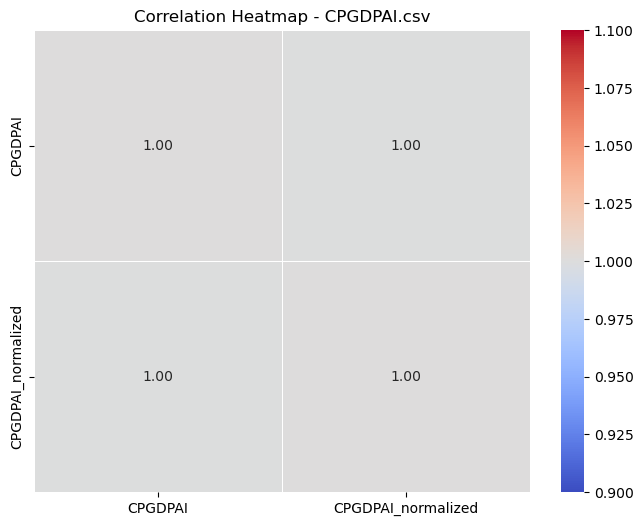

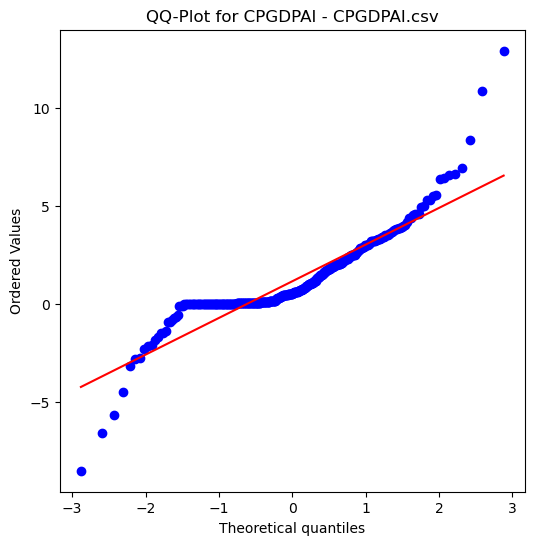


Outlier Count per Column:
CPGDPAI               17
CPGDPAI_normalized    17
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
              Feature      VIF
0             CPGDPAI  4.02866
1  CPGDPAI_normalized  4.02866

--- Analyzing T10Y2Y.csv ---

Correlation Matrix:
                   T10Y2Y  T10Y2Y_normalized
T10Y2Y                1.0                1.0
T10Y2Y_normalized     1.0                1.0


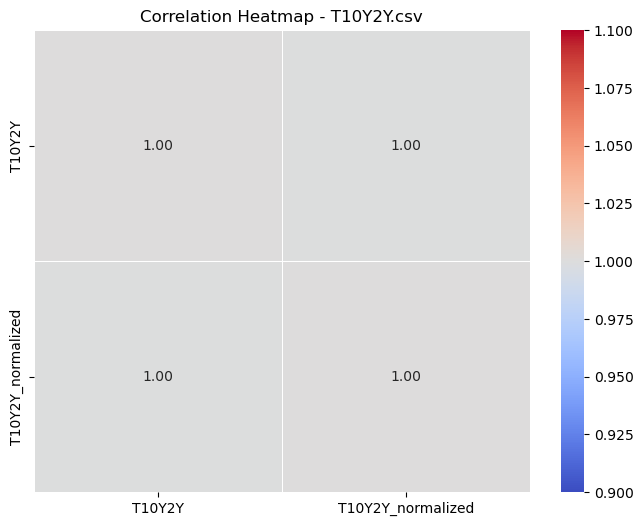

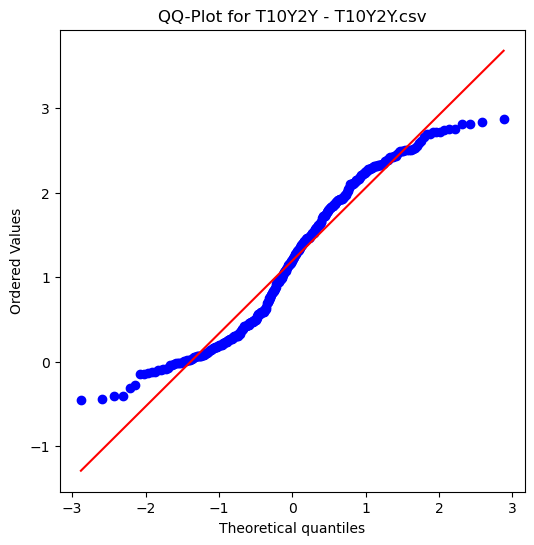


Outlier Count per Column:
T10Y2Y               0
T10Y2Y_normalized    0
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
             Feature       VIF
0             T10Y2Y  1.537143
1  T10Y2Y_normalized  1.537143

--- Analyzing PERMIT.csv ---

Correlation Matrix:
                   PERMIT  PERMIT_normalized
PERMIT                1.0                1.0
PERMIT_normalized     1.0                1.0


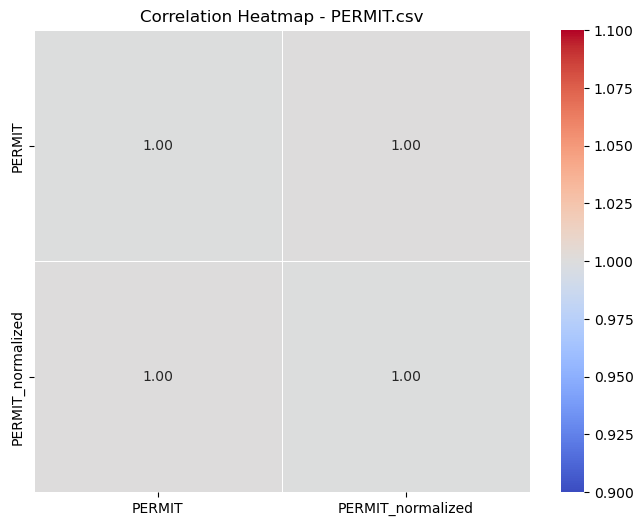

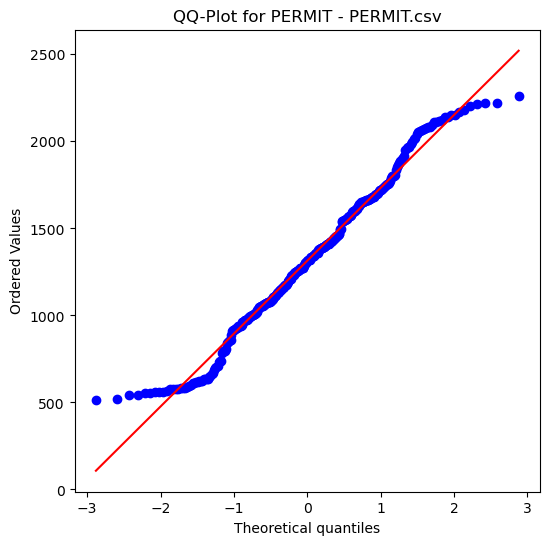


Outlier Count per Column:
PERMIT               0
PERMIT_normalized    0
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
             Feature       VIF
0             PERMIT  1.101739
1  PERMIT_normalized  1.101739

--- Analyzing AWHAETP.csv ---

Correlation Matrix:
                    AWHAETP  AWHAETP_normalized
AWHAETP                 1.0                 1.0
AWHAETP_normalized      1.0                 1.0


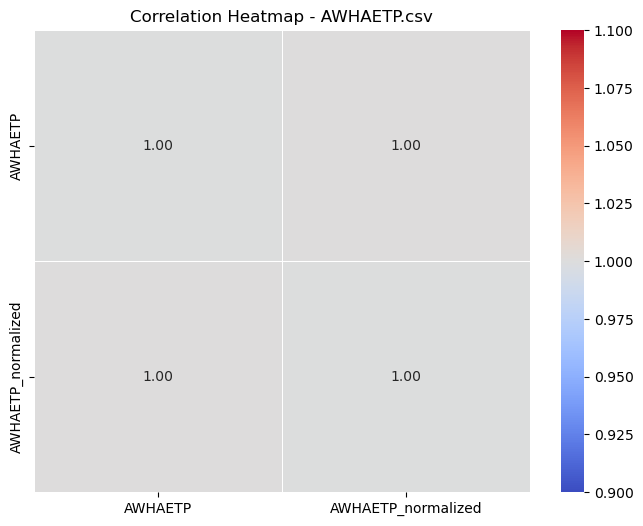

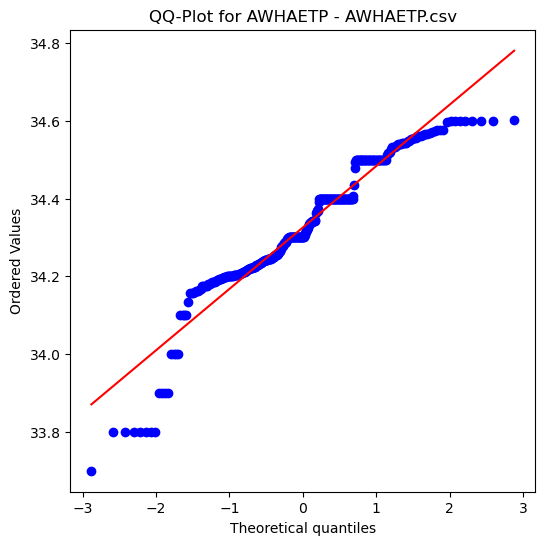


Outlier Count per Column:
AWHAETP               12
AWHAETP_normalized    12
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
              Feature       VIF
0             AWHAETP  1.000022
1  AWHAETP_normalized  1.000022

--- Analyzing UMCSENT.csv ---

Correlation Matrix:
                    UMCSENT  UMCSENT_normalized
UMCSENT                 1.0                 1.0
UMCSENT_normalized      1.0                 1.0


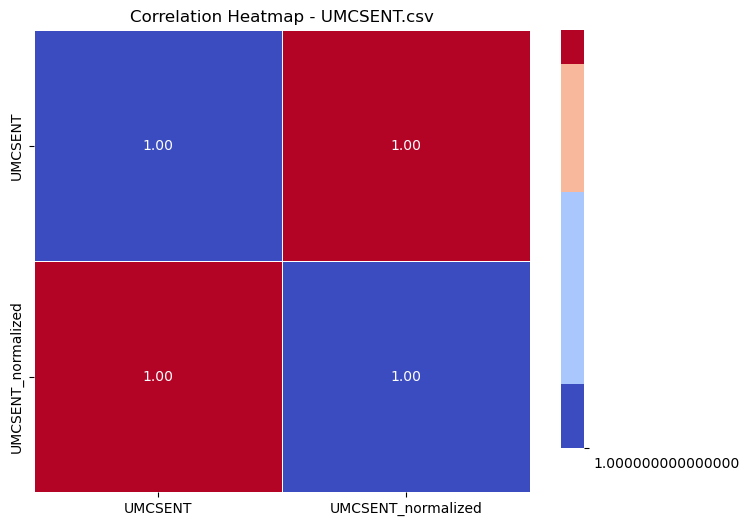

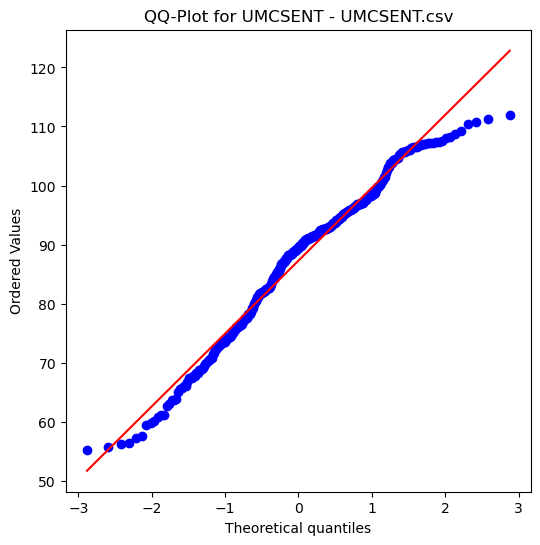


Outlier Count per Column:
UMCSENT               0
UMCSENT_normalized    0
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
              Feature       VIF
0             UMCSENT  1.020134
1  UMCSENT_normalized  1.020134

--- Analyzing SP500.csv ---

Correlation Matrix:
                  SP500  SP500_normalized
SP500               1.0               1.0
SP500_normalized    1.0               1.0


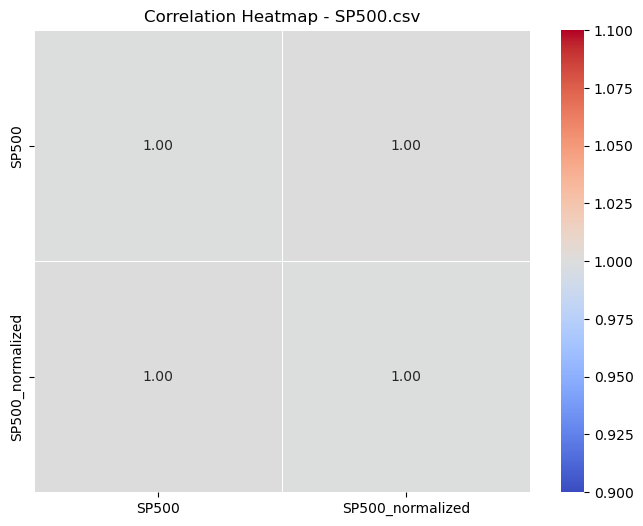

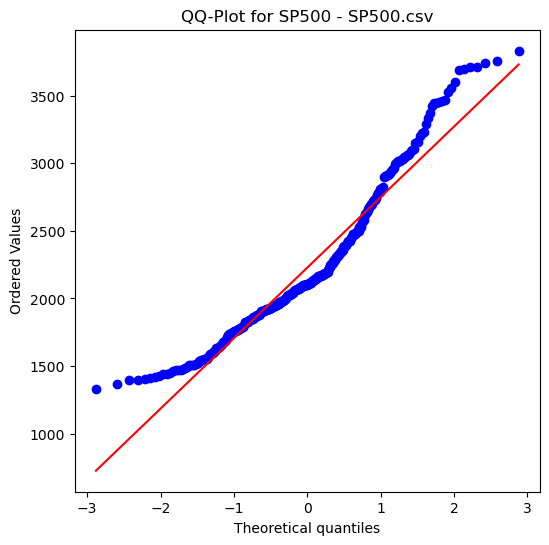


Outlier Count per Column:
SP500               16
SP500_normalized    16
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
            Feature       VIF
0             SP500  1.057537
1  SP500_normalized  1.057537

--- Analyzing TTLCONS.csv ---

Correlation Matrix:
                    TTLCONS  TTLCONS_normalized
TTLCONS                 1.0                 1.0
TTLCONS_normalized      1.0                 1.0


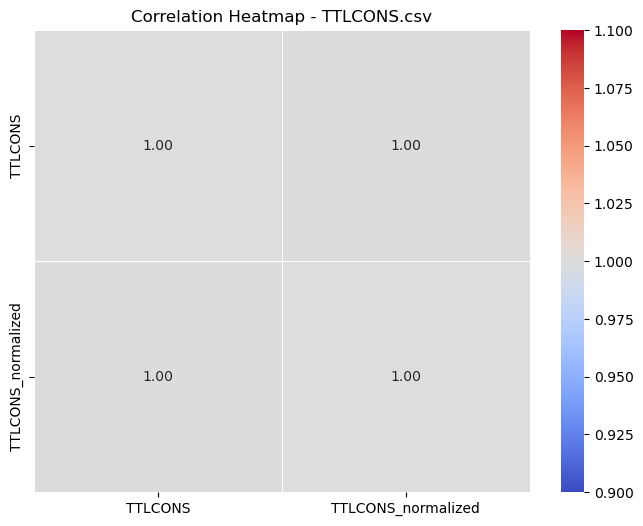

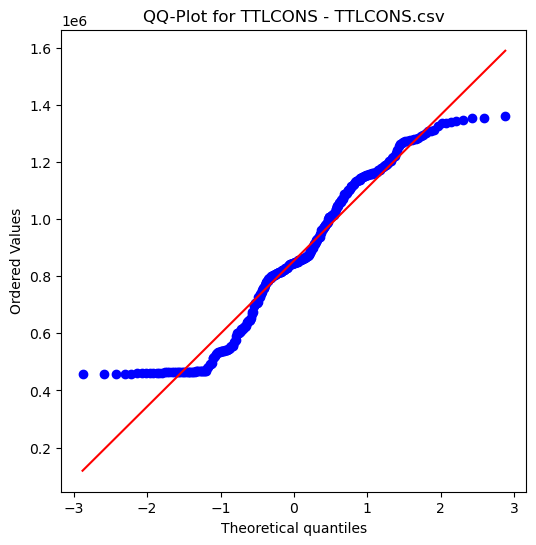


Outlier Count per Column:
TTLCONS               0
TTLCONS_normalized    0
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
              Feature       VIF
0             TTLCONS  1.092156
1  TTLCONS_normalized  1.092156

--- Analyzing ATCGNO.csv ---

Correlation Matrix:
                   ATCGNO  ATCGNO_normalized
ATCGNO                1.0                1.0
ATCGNO_normalized     1.0                1.0


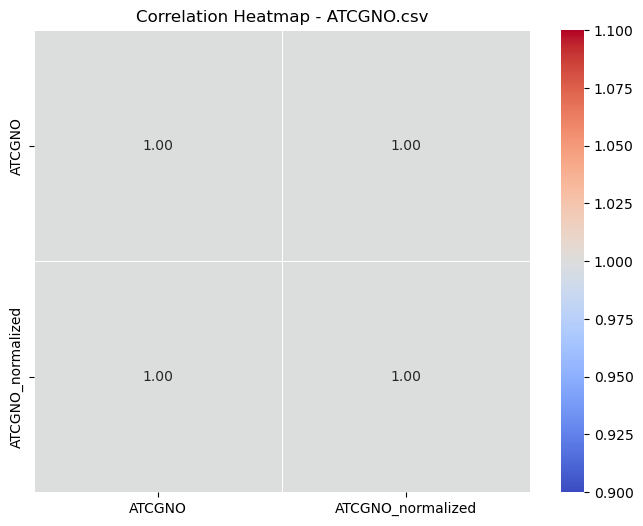

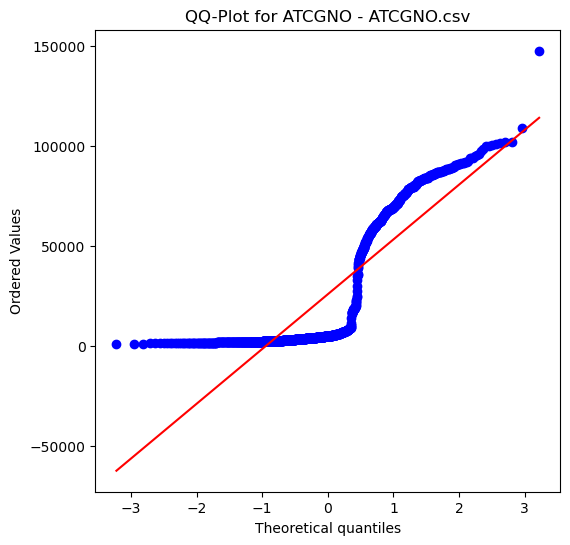


Outlier Count per Column:
ATCGNO               1
ATCGNO_normalized    1
dtype: int64

Variance Inflation Factor (VIF) for Multicollinearity Check:
             Feature       VIF
0             ATCGNO  2.530024
1  ATCGNO_normalized  2.530024


In [56]:

# Iterate over all CSV files and process them
for file_name in csv_files:
    file_path = os.path.join(directory, file_name)

    # Read CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Remove any extra spaces in column names
    df.columns = df.columns.str.strip()

    # Ensure 'Date' is correctly parsed as a datetime column
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Select only numerical columns for analysis
    numeric_cols = df.select_dtypes(include=['number']).columns

    if len(numeric_cols) == 0:
        print(f"\nSkipping {file_name} - No numerical columns found.")
        continue

    print(f"\n--- Analyzing {file_name} ---")

    # 1. Compute Correlation Matrix
    corr_matrix = df[numeric_cols].corr()
    print("\nCorrelation Matrix:")
    print(corr_matrix)

    # Plot Correlation Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation Heatmap - {file_name}")
    plt.show()

    # 2. QQ-Plot for Normality Check (First numerical column)
    first_col = numeric_cols[0]
    plt.figure(figsize=(6, 6))
    stats.probplot(df[first_col].dropna(), dist="norm", plot=plt)
    plt.title(f"QQ-Plot for {first_col} - {file_name}")
    plt.show()

    # 3. Outlier Detection using IQR Method
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
    
    print("\nOutlier Count per Column:")
    print(outliers)

    # 4. Multicollinearity Check using VIF
    if len(numeric_cols) > 1:
        X = df[numeric_cols].dropna()
        vif_data = pd.DataFrame()
        vif_data["Feature"] = numeric_cols
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(numeric_cols))]

        print("\nVariance Inflation Factor (VIF) for Multicollinearity Check:")
        print(vif_data)

## Feature engineering

In [60]:
# Function to add lag features, moving averages, and trend indicators
def feature_engineering(df):
    # Select only numerical columns (excluding Date)
    numeric_cols = df.select_dtypes(include=['number']).columns

    if len(numeric_cols) == 0:
        return df  # Skip if no numerical columns found

    for col in numeric_cols:
        # Add lag features (1-month, 3-months, and 6-months)
        df[f"{col}_lag1"] = df[col].shift(1)
        df[f"{col}_lag3"] = df[col].shift(3)
        df[f"{col}_lag6"] = df[col].shift(6)

        # Moving Averages (MA)
        df[f"{col}_MA3"] = df[col].rolling(window=3).mean()
        df[f"{col}_MA6"] = df[col].rolling(window=6).mean()
        df[f"{col}_MA12"] = df[col].rolling(window=12).mean()

        # Rolling statistics (std, min, max)
        df[f"{col}_rolling_std3"] = df[col].rolling(window=3).std()
        df[f"{col}_rolling_min3"] = df[col].rolling(window=3).min()
        df[f"{col}_rolling_max3"] = df[col].rolling(window=3).max()

        # Trend indicators (Slope of Moving Average)
        df[f"{col}_trend3"] = df[f"{col}_MA3"].diff()

        # Percentage Change
        df[f"{col}_pct_change"] = df[col].pct_change()

    return df

# Iterate over all CSV files and process them
for file_name in csv_files:
    file_path = os.path.join(directory, file_name)

    # Read CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Remove any extra spaces in column names
    df.columns = df.columns.str.strip()

    # Ensure 'Date' is correctly parsed as a datetime column
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Apply feature engineering
    df = feature_engineering(df)

    # Save the transformed data back to the same file
    output_path = os.path.join(directory, file_name)
    df.to_csv(output_path, index=False)

    print(f"Feature engineering completed for: {file_name}")

Feature engineering completed for: CPGDPAI.csv
Feature engineering completed for: T10Y2Y.csv
Feature engineering completed for: PERMIT.csv
Feature engineering completed for: AWHAETP.csv
Feature engineering completed for: UMCSENT.csv
Feature engineering completed for: SP500.csv
Feature engineering completed for: TTLCONS.csv
Feature engineering completed for: ATCGNO.csv


## stationarity test


--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI) ---
ADF Statistic: -5.009337171304322
P-Value: 2.1267960353183466e-05
Critical Values:
   1%: -3.4494474563375737
   5%: -2.8699542285903887
   10%: -2.5712527305187987
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

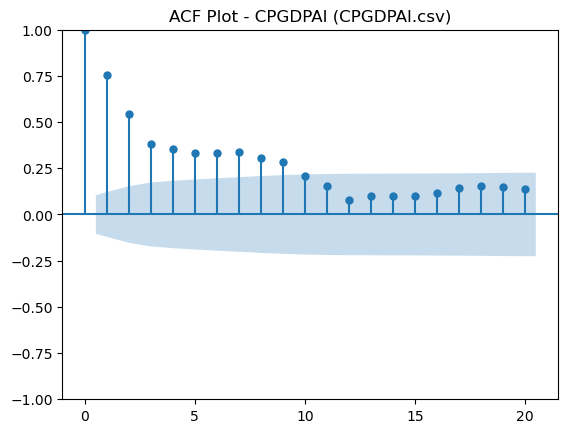

<Figure size 800x400 with 0 Axes>

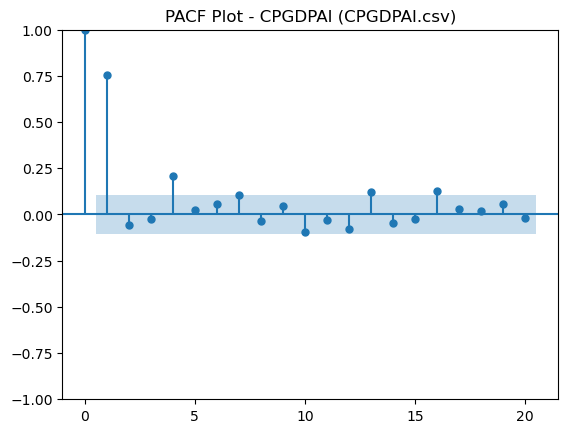

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized) ---
ADF Statistic: -5.009337171304319
P-Value: 2.1267960353183778e-05
Critical Values:
   1%: -3.4494474563375737
   5%: -2.8699542285903887
   10%: -2.5712527305187987
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

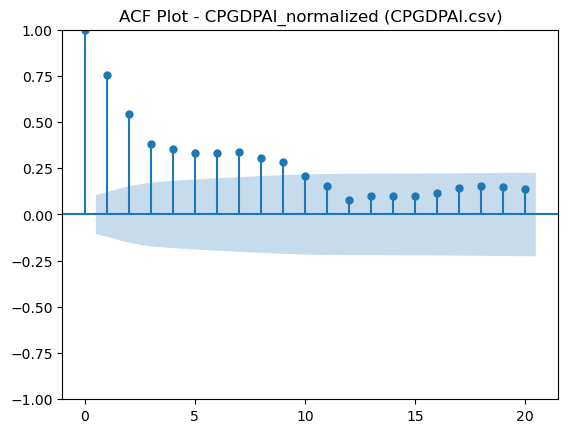

<Figure size 800x400 with 0 Axes>

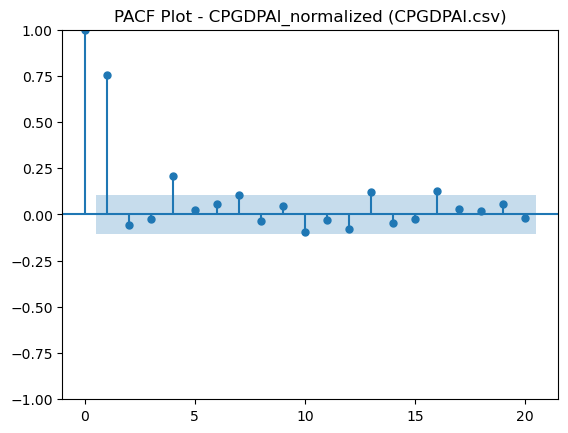

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_lag1) ---
ADF Statistic: -5.031818093289749
P-Value: 1.9190469623955993e-05
Critical Values:
   1%: -3.4495033946549123
   5%: -2.8699787979596136
   10%: -2.5712658305164955
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

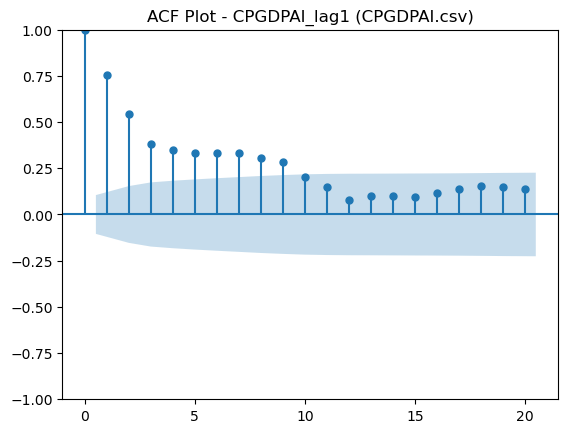

<Figure size 800x400 with 0 Axes>

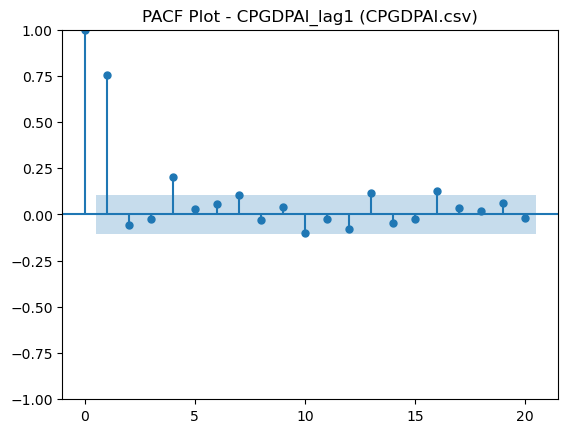

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_lag3) ---
ADF Statistic: -5.01495349230514
P-Value: 2.0729493435444035e-05
Critical Values:
   1%: -3.4496162602188187
   5%: -2.870028369720798
   10%: -2.5712922615505627
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

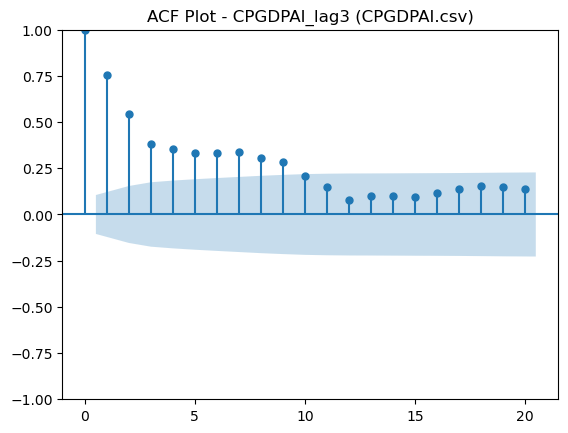

<Figure size 800x400 with 0 Axes>

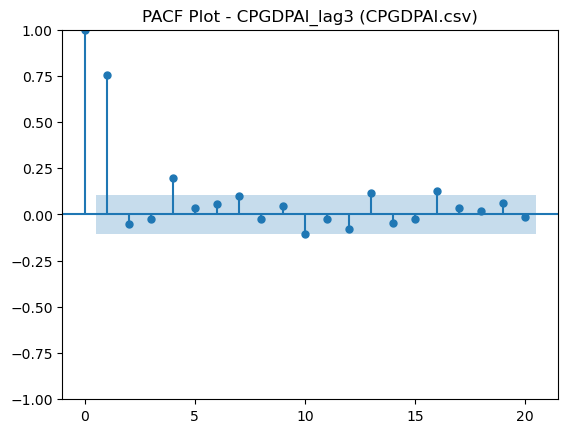

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_lag6) ---
ADF Statistic: -3.622549418183789
P-Value: 0.005344279487071302
Critical Values:
   1%: -3.449962981927952
   5%: -2.870180642420163
   10%: -2.5713734527352607
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

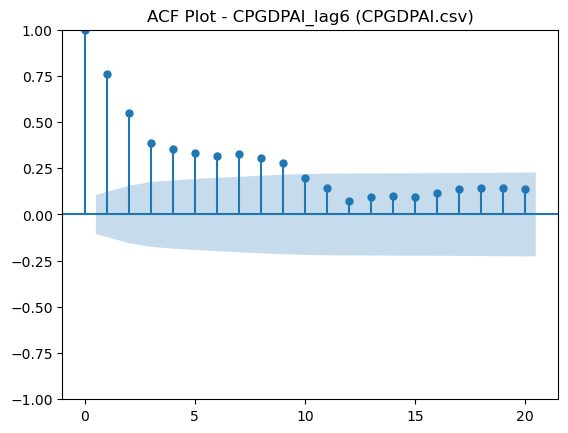

<Figure size 800x400 with 0 Axes>

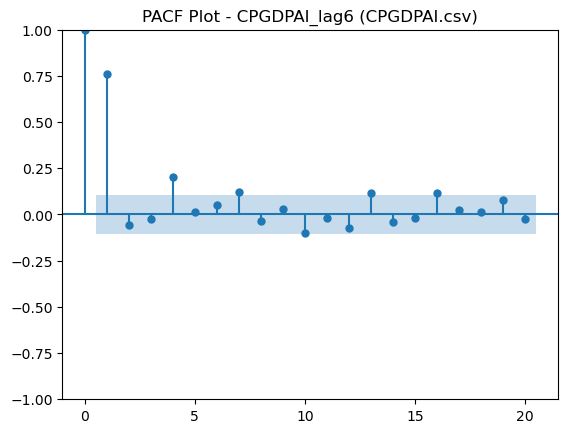

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_MA3) ---
ADF Statistic: -2.7077449150907316
P-Value: 0.07270762252849712
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522
The series is likely non-stationary (p-value >= 0.05). Consider differencing.


<Figure size 800x400 with 0 Axes>

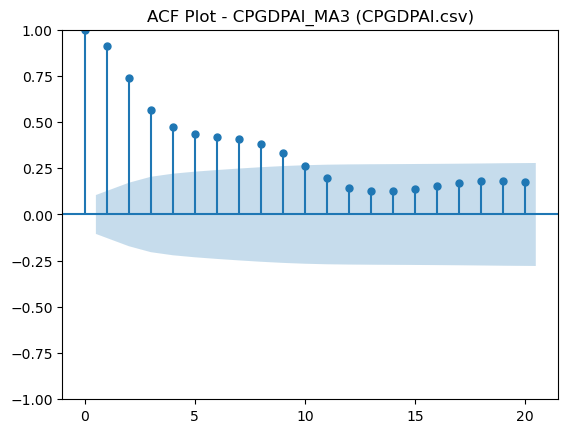

<Figure size 800x400 with 0 Axes>

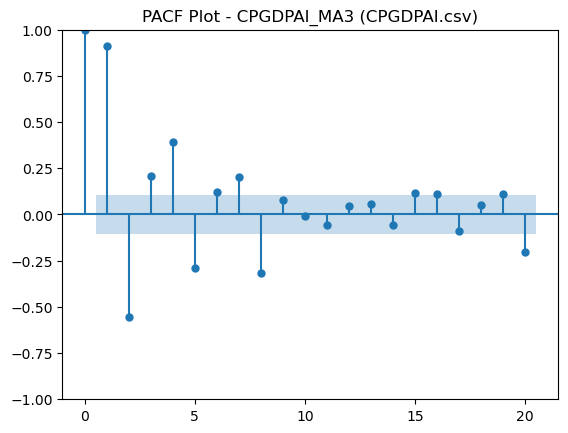

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_MA6) ---
ADF Statistic: -2.8946007946316374
P-Value: 0.04597946369830834
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

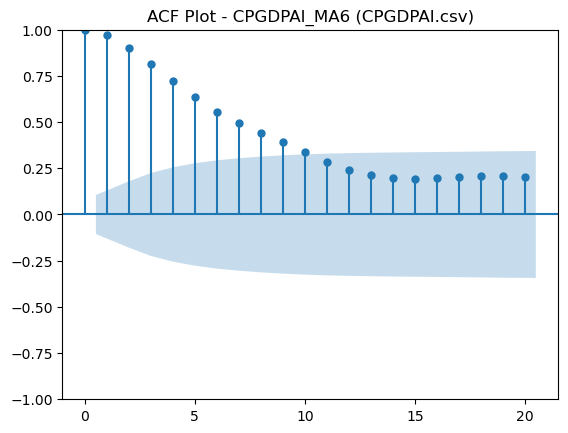

<Figure size 800x400 with 0 Axes>

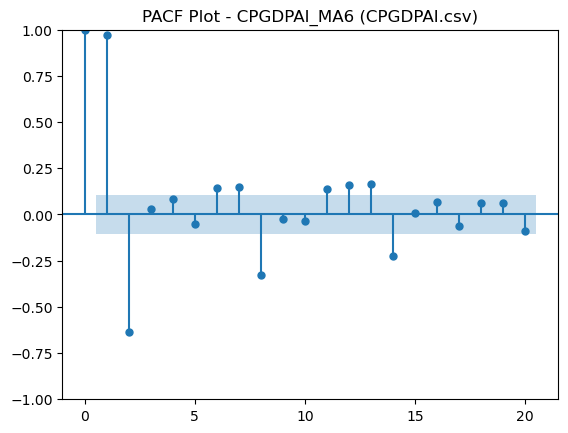

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_MA12) ---
ADF Statistic: -2.086786609025061
P-Value: 0.24986085828335214
Critical Values:
   1%: -3.450886958636161
   5%: -2.870586350823483
   10%: -2.5715897843576827
The series is likely non-stationary (p-value >= 0.05). Consider differencing.


<Figure size 800x400 with 0 Axes>

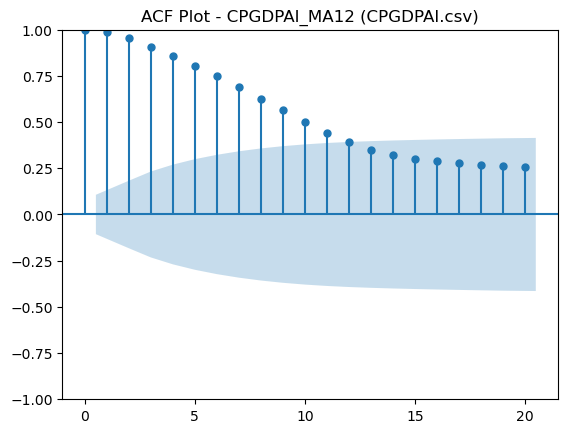

<Figure size 800x400 with 0 Axes>

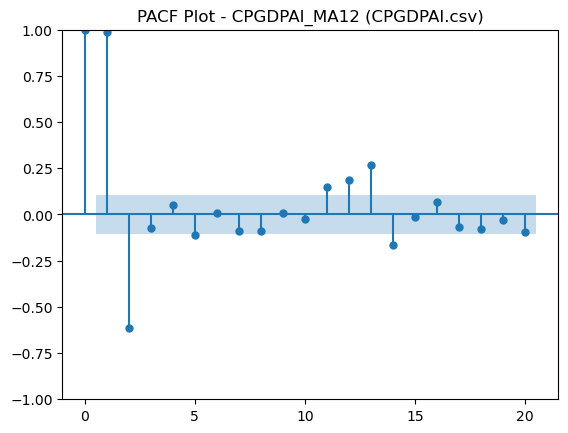

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_rolling_std3) ---
ADF Statistic: -3.193750360478494
P-Value: 0.02034929489222753
Critical Values:
   1%: -3.449846029628477
   5%: -2.870129281376164
   10%: -2.5713460670144603
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

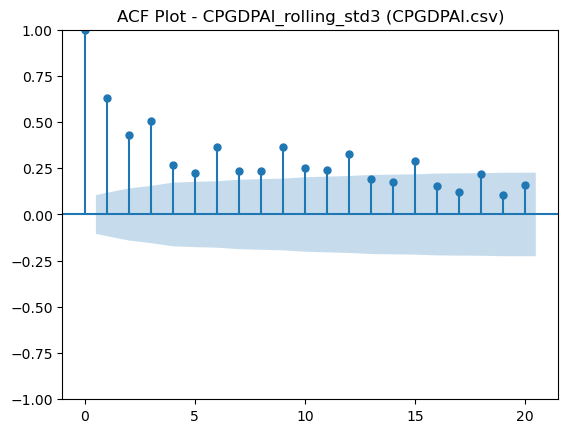

<Figure size 800x400 with 0 Axes>

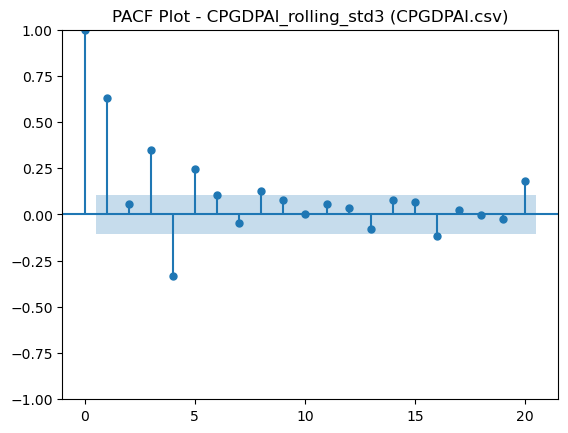

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_rolling_min3) ---
ADF Statistic: -4.9904977960708345
P-Value: 2.317449750667973e-05
Critical Values:
   1%: -3.4499043309021955
   5%: -2.870154885338925
   10%: -2.5713597190254385
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

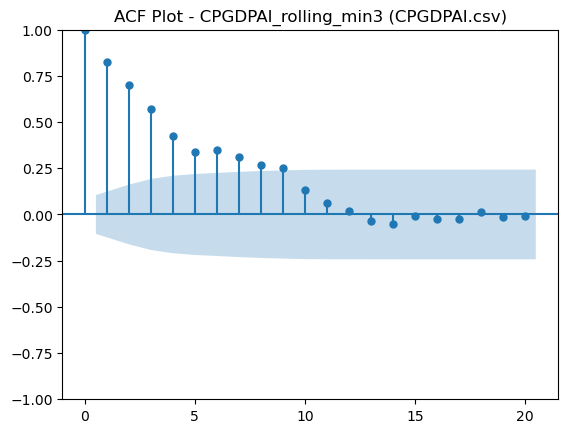

<Figure size 800x400 with 0 Axes>

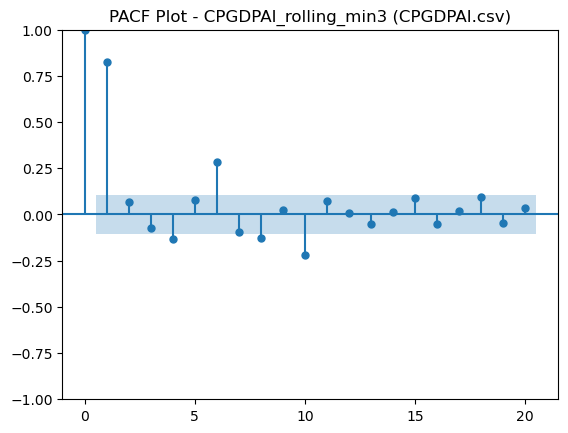

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_rolling_max3) ---
ADF Statistic: -3.301970299753127
P-Value: 0.014790631431947693
Critical Values:
   1%: -3.4499043309021955
   5%: -2.870154885338925
   10%: -2.5713597190254385
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

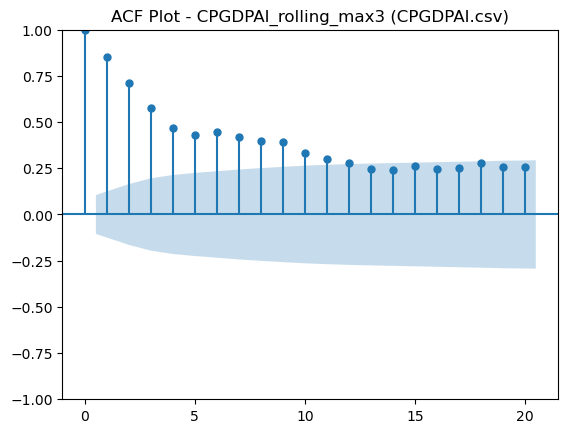

<Figure size 800x400 with 0 Axes>

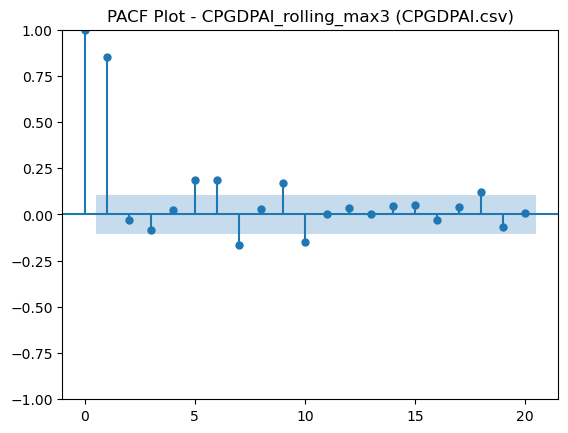

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_trend3) ---
ADF Statistic: -6.971560273281949
P-Value: 8.638385697032082e-10
Critical Values:
   1%: -3.4504451681828194
   5%: -2.870392380216117
   10%: -2.571486353732897
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

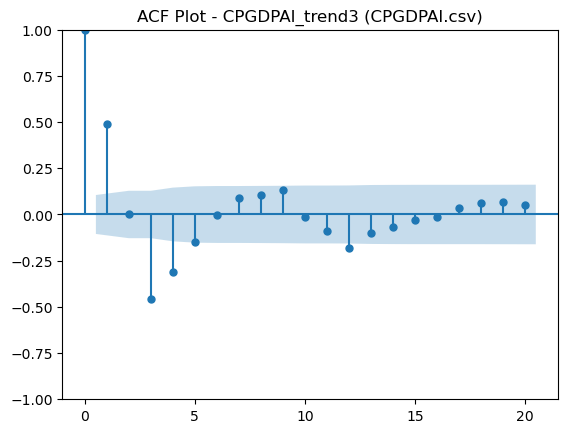

<Figure size 800x400 with 0 Axes>

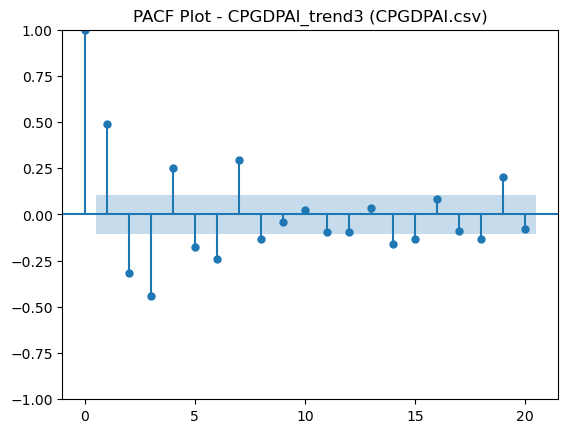

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_pct_change) ---
ADF Statistic: -18.608190798140658
P-Value: 2.0662840310277337e-30
Critical Values:
   1%: -3.449336554273722
   5%: -2.8699055166063085
   10%: -2.571226758215748
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

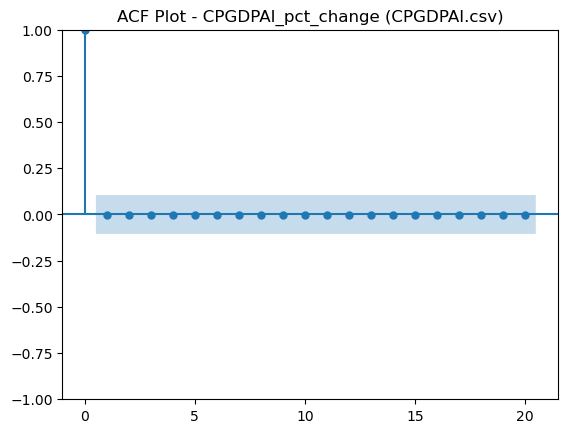

<Figure size 800x400 with 0 Axes>

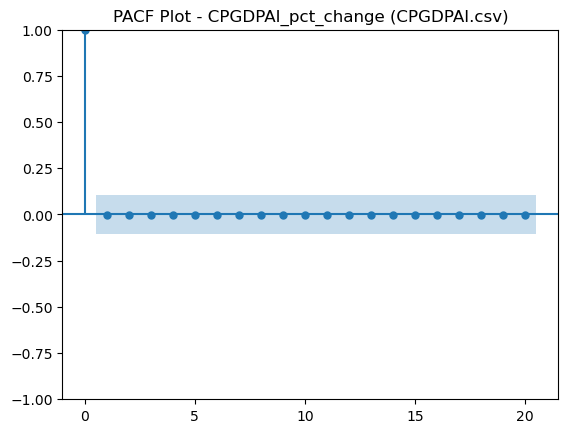

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_lag1) ---
ADF Statistic: -5.031818093289749
P-Value: 1.9190469623955993e-05
Critical Values:
   1%: -3.4495033946549123
   5%: -2.8699787979596136
   10%: -2.5712658305164955
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

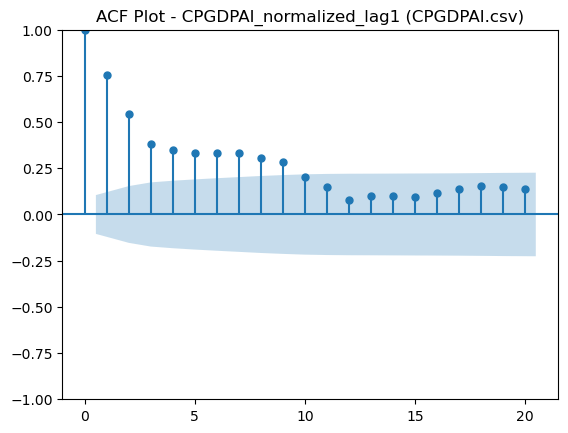

<Figure size 800x400 with 0 Axes>

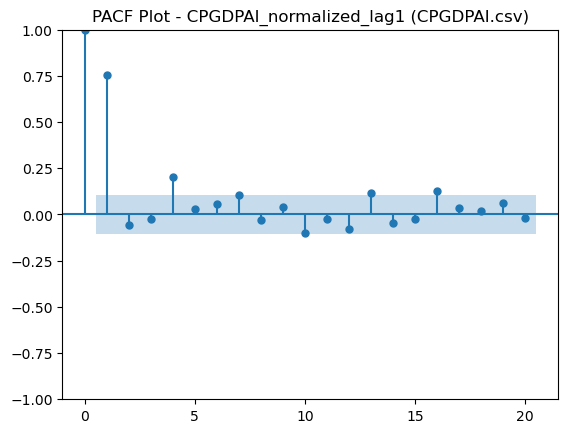

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_lag3) ---
ADF Statistic: -5.01495349230514
P-Value: 2.0729493435444035e-05
Critical Values:
   1%: -3.4496162602188187
   5%: -2.870028369720798
   10%: -2.5712922615505627
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

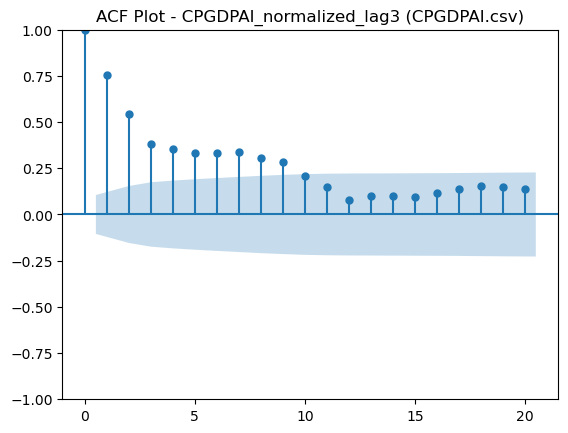

<Figure size 800x400 with 0 Axes>

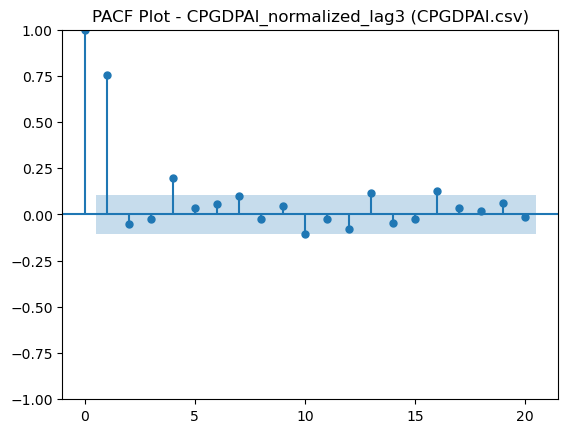

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_lag6) ---
ADF Statistic: -3.622549418183782
P-Value: 0.005344279487071414
Critical Values:
   1%: -3.449962981927952
   5%: -2.870180642420163
   10%: -2.5713734527352607
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

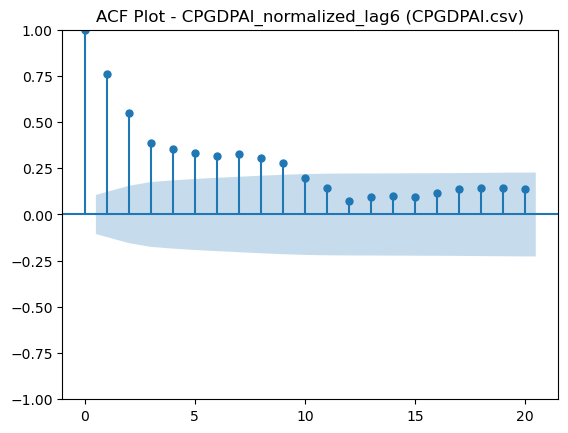

<Figure size 800x400 with 0 Axes>

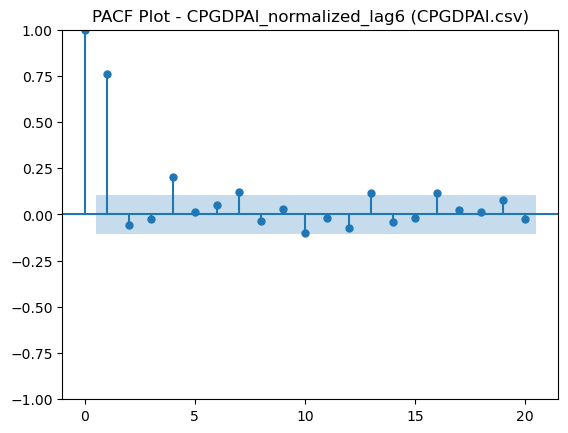

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_MA3) ---
ADF Statistic: -2.707744915090722
P-Value: 0.07270762252849877
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522
The series is likely non-stationary (p-value >= 0.05). Consider differencing.


<Figure size 800x400 with 0 Axes>

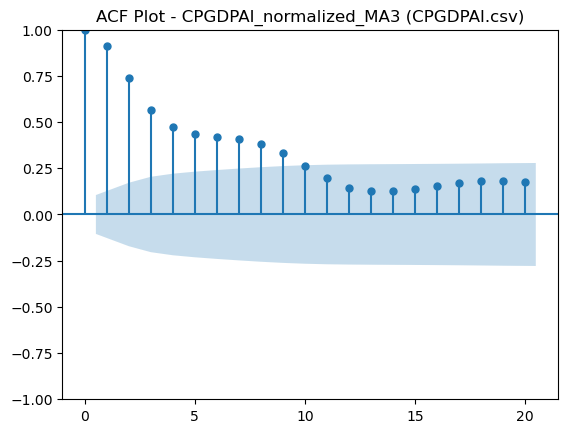

<Figure size 800x400 with 0 Axes>

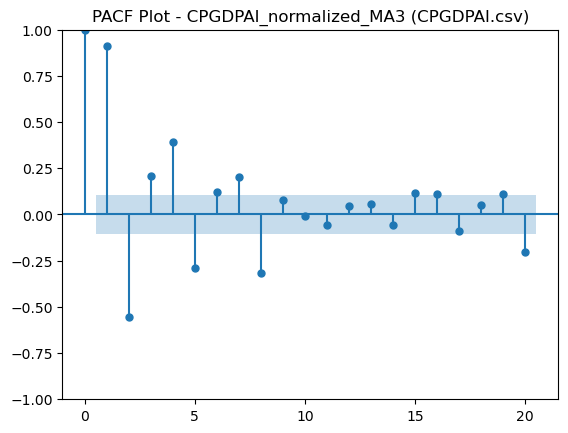

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_MA6) ---
ADF Statistic: -2.8946007946316286
P-Value: 0.04597946369830938
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

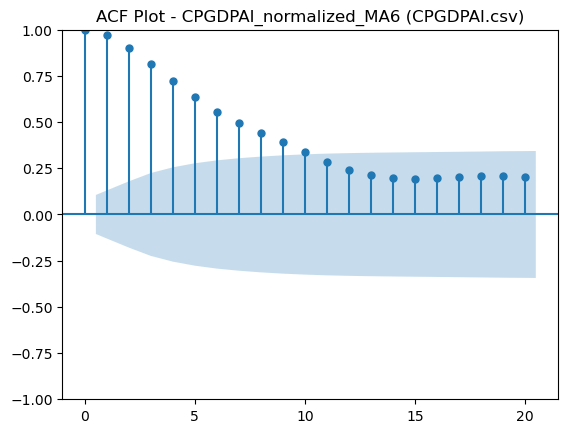

<Figure size 800x400 with 0 Axes>

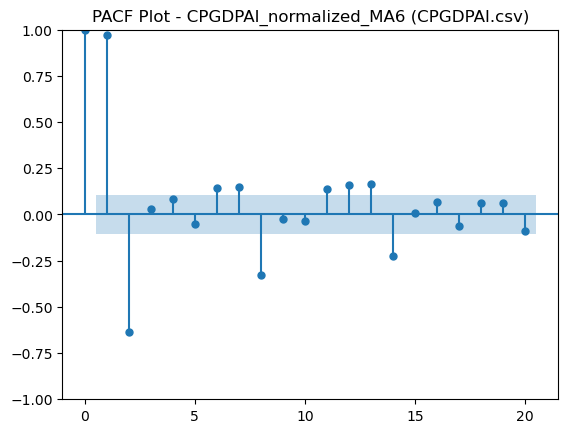

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_MA12) ---
ADF Statistic: -2.0867866090250824
P-Value: 0.24986085828334353
Critical Values:
   1%: -3.450886958636161
   5%: -2.870586350823483
   10%: -2.5715897843576827
The series is likely non-stationary (p-value >= 0.05). Consider differencing.


<Figure size 800x400 with 0 Axes>

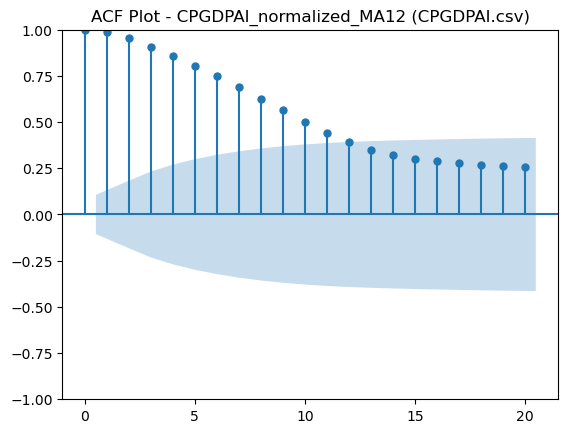

<Figure size 800x400 with 0 Axes>

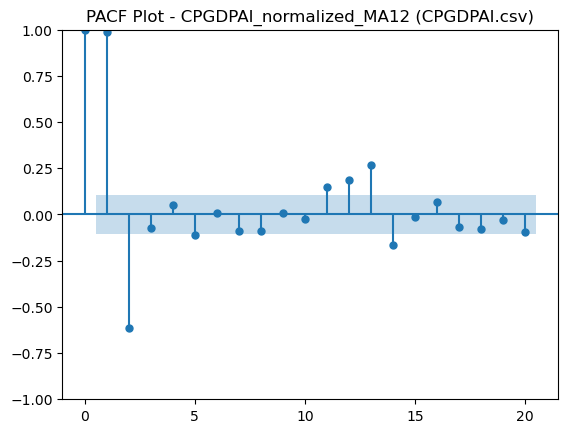

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_rolling_std3) ---
ADF Statistic: -3.193750360478231
P-Value: 0.020349294892242988
Critical Values:
   1%: -3.449846029628477
   5%: -2.870129281376164
   10%: -2.5713460670144603
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

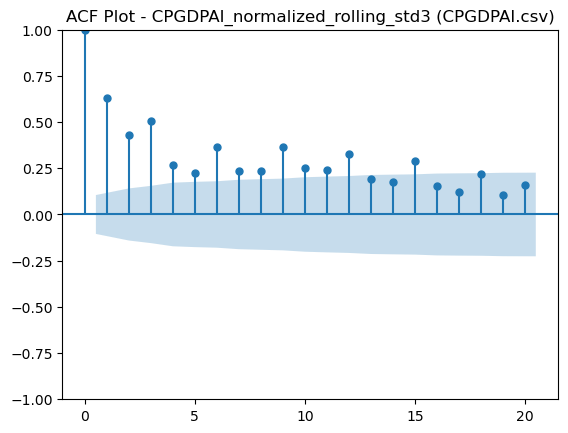

<Figure size 800x400 with 0 Axes>

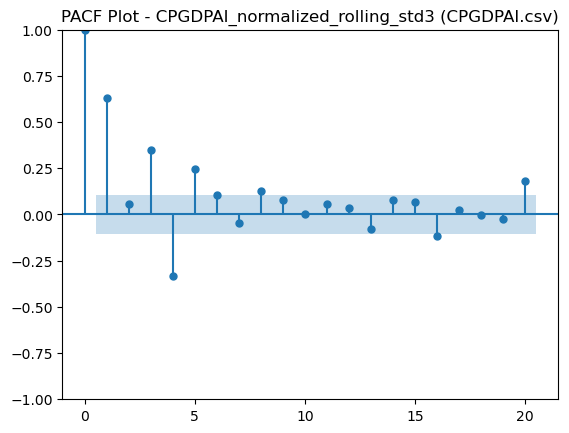

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_rolling_min3) ---
ADF Statistic: -4.990497796070814
P-Value: 2.3174497506682073e-05
Critical Values:
   1%: -3.4499043309021955
   5%: -2.870154885338925
   10%: -2.5713597190254385
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

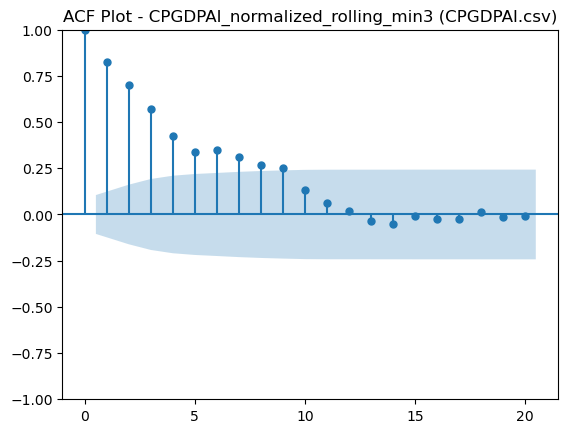

<Figure size 800x400 with 0 Axes>

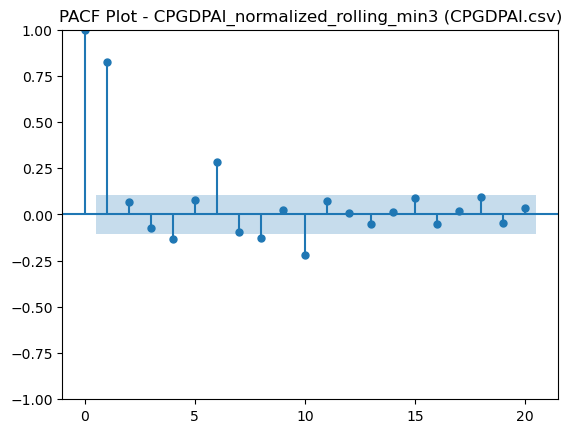

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_rolling_max3) ---
ADF Statistic: -3.3019702997531395
P-Value: 0.014790631431947162
Critical Values:
   1%: -3.4499043309021955
   5%: -2.870154885338925
   10%: -2.5713597190254385
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

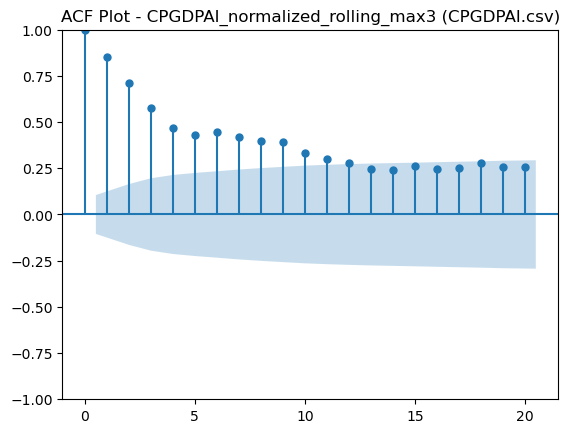

<Figure size 800x400 with 0 Axes>

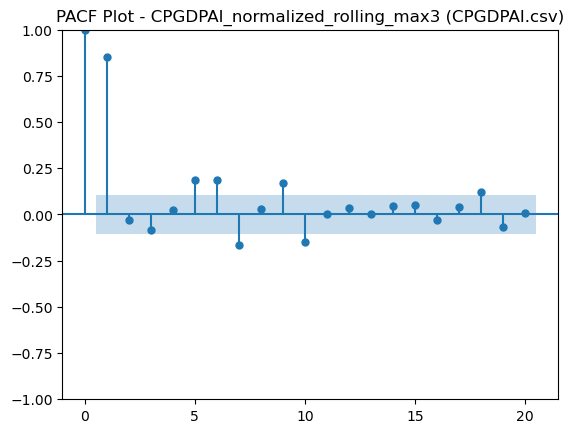

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_trend3) ---
ADF Statistic: -6.971560273281962
P-Value: 8.638385697031548e-10
Critical Values:
   1%: -3.4504451681828194
   5%: -2.870392380216117
   10%: -2.571486353732897
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

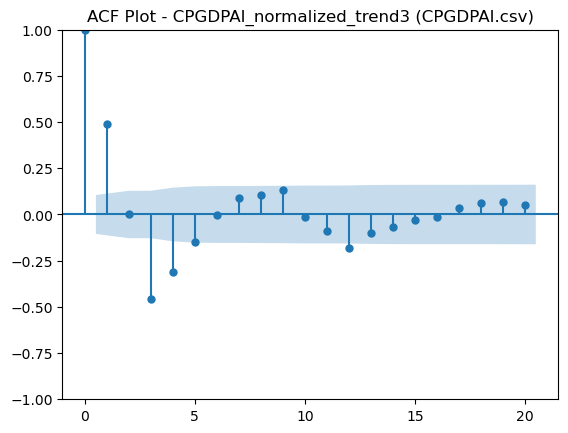

<Figure size 800x400 with 0 Axes>

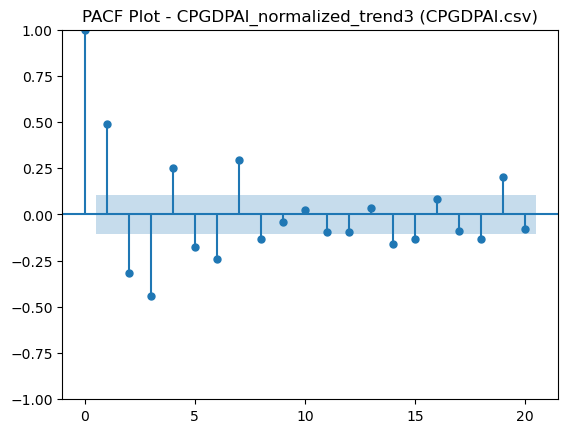

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for CPGDPAI.csv (CPGDPAI_normalized_pct_change) ---
ADF Statistic: -18.62367259997487
P-Value: 2.0602756572231613e-30
Critical Values:
   1%: -3.449336554273722
   5%: -2.8699055166063085
   10%: -2.571226758215748
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

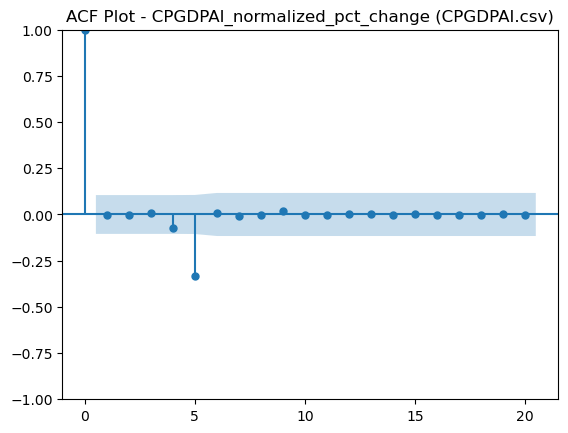

<Figure size 800x400 with 0 Axes>

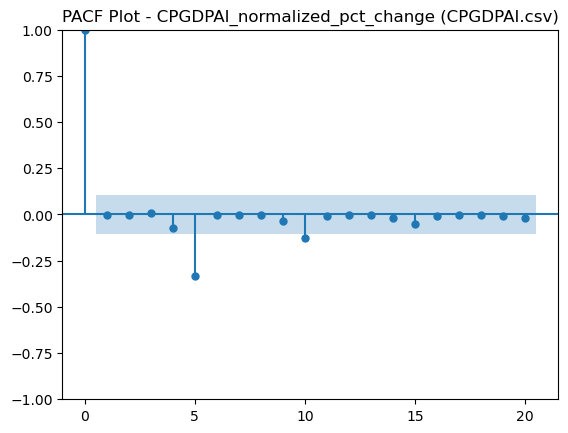

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y) ---
ADF Statistic: -3.165752885934377
P-Value: 0.022054607303528935
Critical Values:
   1%: -3.450141065277327
   5%: -2.870258846235788
   10%: -2.571415151457764
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

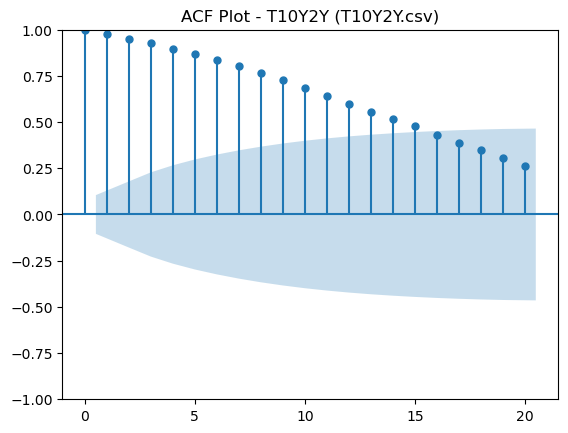

<Figure size 800x400 with 0 Axes>

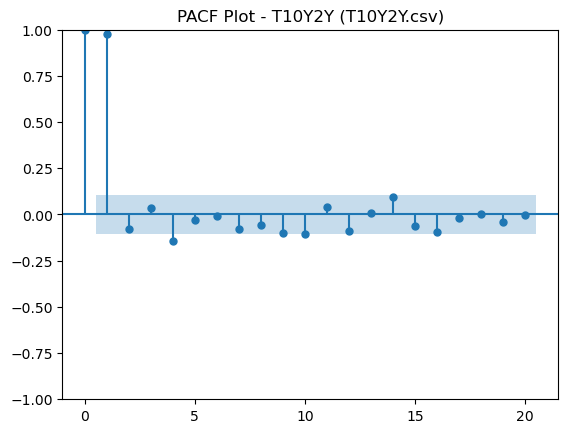

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_normalized) ---
ADF Statistic: -3.165752885863013
P-Value: 0.022054607308028905
Critical Values:
   1%: -3.450141065277327
   5%: -2.870258846235788
   10%: -2.571415151457764
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

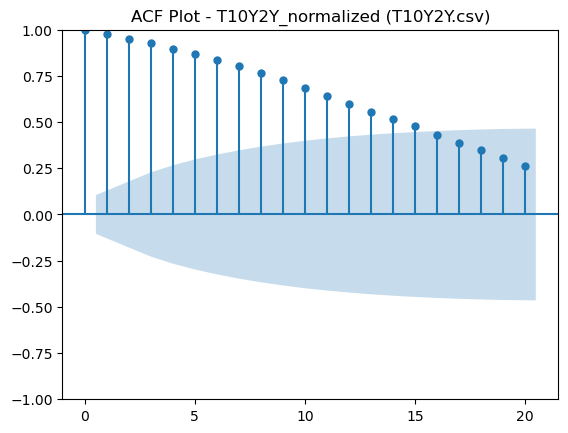

<Figure size 800x400 with 0 Axes>

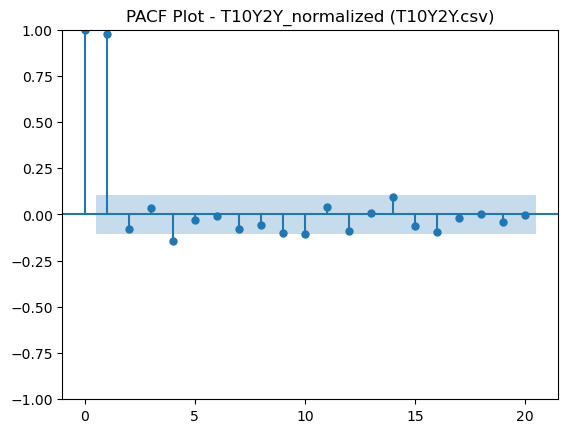

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_lag1) ---
ADF Statistic: -3.1395687271622403
P-Value: 0.023760162252099197
Critical Values:
   1%: -3.4502011472639724
   5%: -2.8702852297358983
   10%: -2.5714292194077513
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

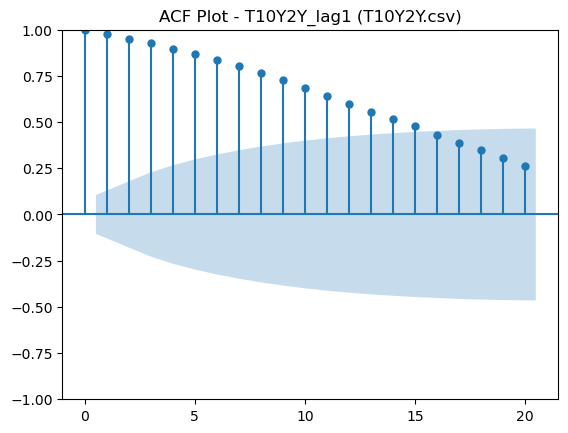

<Figure size 800x400 with 0 Axes>

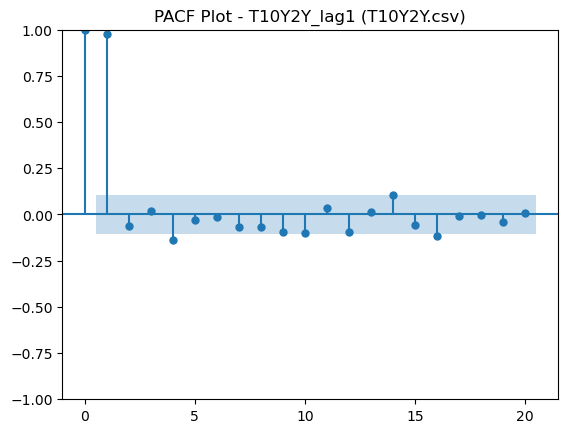

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_lag3) ---
ADF Statistic: -3.163177790903367
P-Value: 0.02221750283824013
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

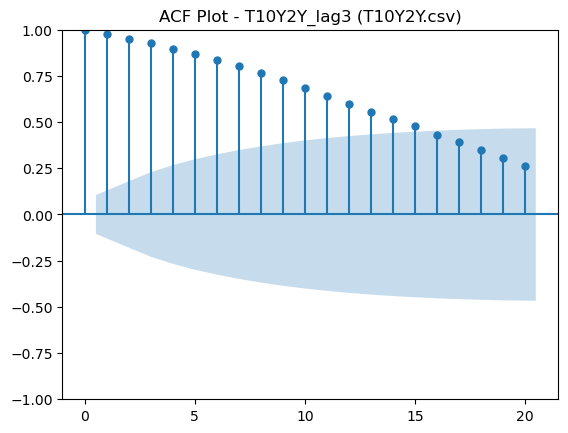

<Figure size 800x400 with 0 Axes>

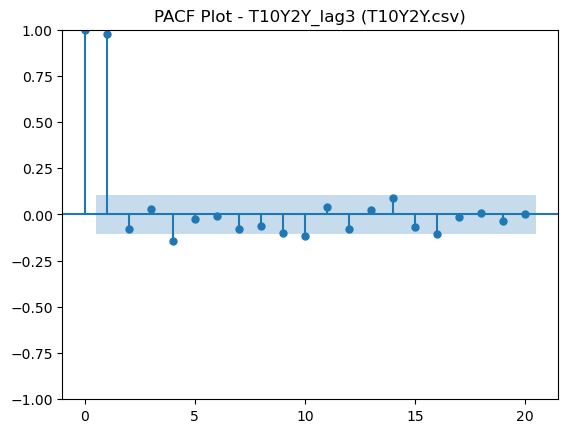

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_lag6) ---
ADF Statistic: -3.145897849834289
P-Value: 0.02333779012751649
Critical Values:
   1%: -3.45050711373316
   5%: -2.8704195794076743
   10%: -2.571500856923753
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

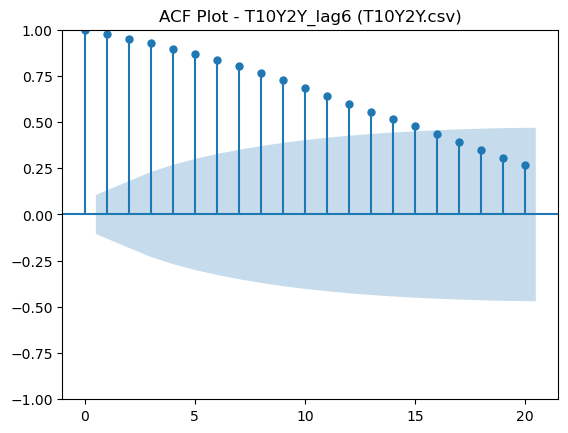

<Figure size 800x400 with 0 Axes>

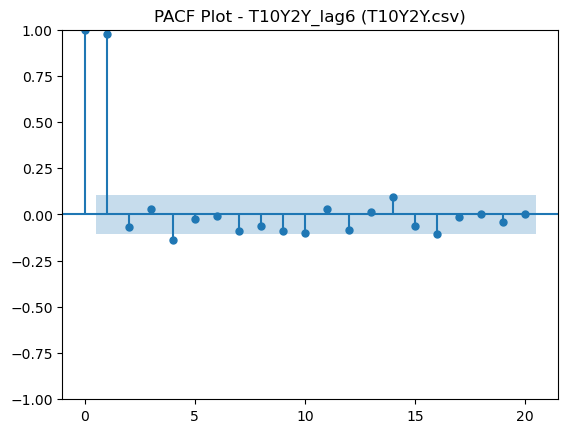

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_MA3) ---
ADF Statistic: -3.2885010359472444
P-Value: 0.015400368480943095
Critical Values:
   1%: -3.450141065277327
   5%: -2.870258846235788
   10%: -2.571415151457764
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

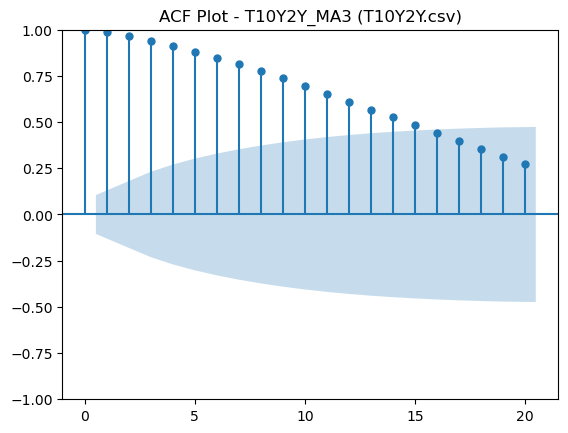

<Figure size 800x400 with 0 Axes>

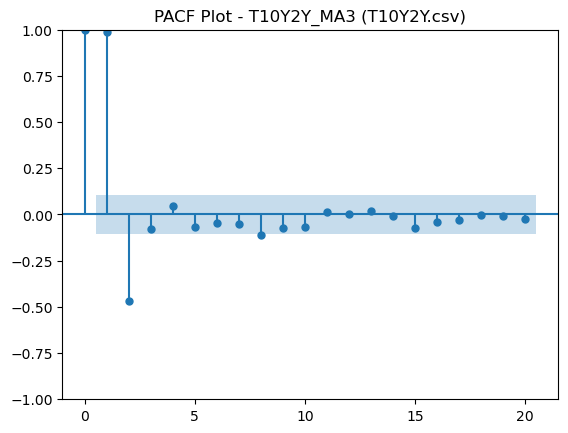

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_MA6) ---
ADF Statistic: -3.6342202242108024
P-Value: 0.0051395208222204825
Critical Values:
   1%: -3.4503224123605194
   5%: -2.870338478726661
   10%: -2.571457612488522
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

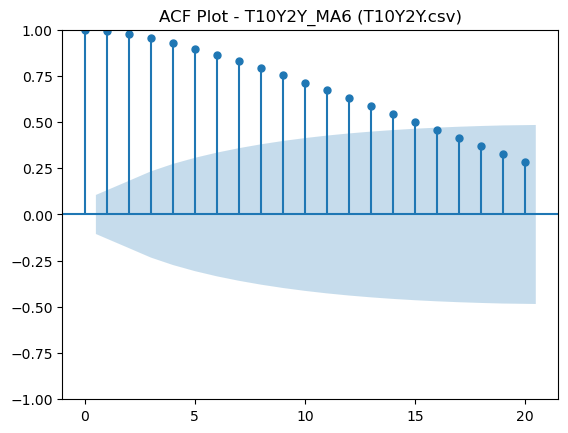

<Figure size 800x400 with 0 Axes>

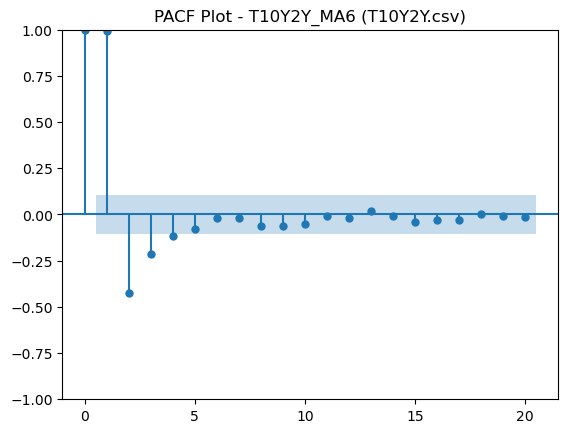

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_MA12) ---
ADF Statistic: -4.072681701958279
P-Value: 0.0010742746208903184
Critical Values:
   1%: -3.4507587628808922
   5%: -2.870530068560499
   10%: -2.5715597727381647
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

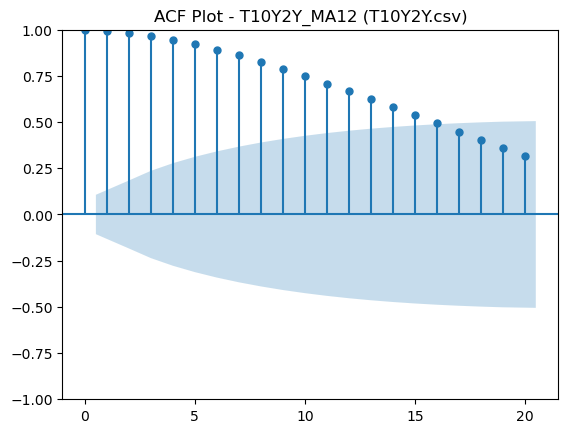

<Figure size 800x400 with 0 Axes>

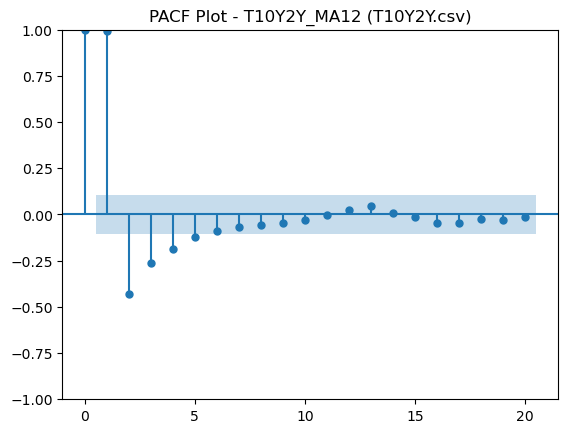

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_rolling_std3) ---
ADF Statistic: -4.7593819528994175
P-Value: 6.499891080593723e-05
Critical Values:
   1%: -3.4497304638968043
   5%: -2.8700785273763487
   10%: -2.571319005190311
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

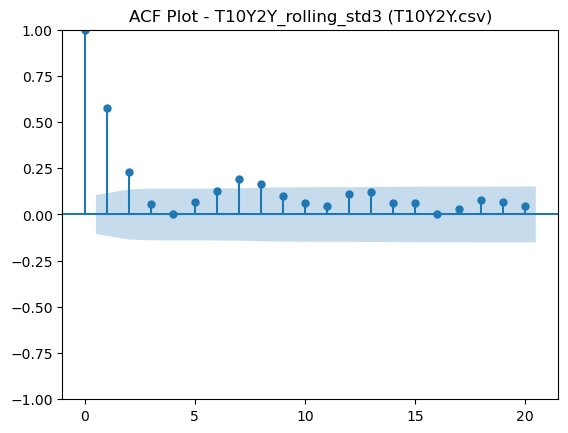

<Figure size 800x400 with 0 Axes>

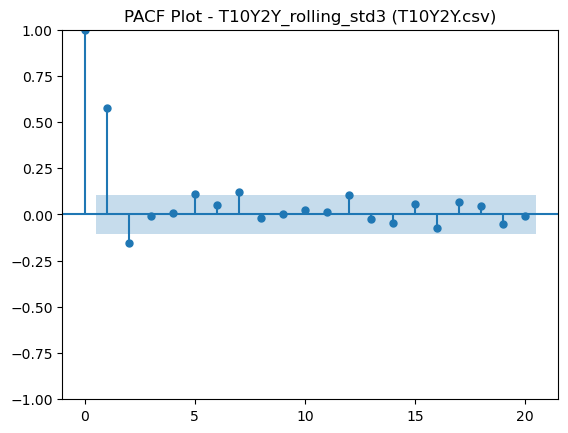

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_rolling_min3) ---
ADF Statistic: -2.982240430949666
P-Value: 0.03658653593567503
Critical Values:
   1%: -3.449846029628477
   5%: -2.870129281376164
   10%: -2.5713460670144603
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

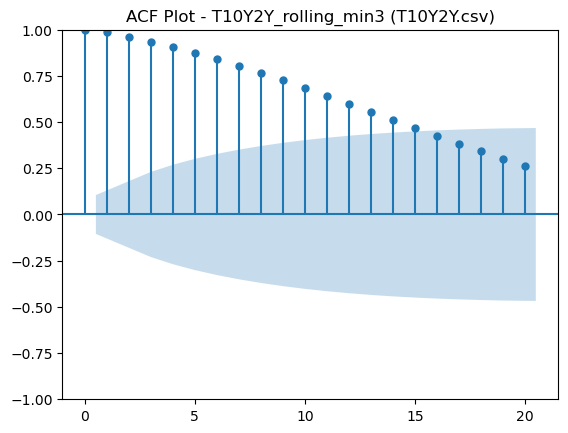

<Figure size 800x400 with 0 Axes>

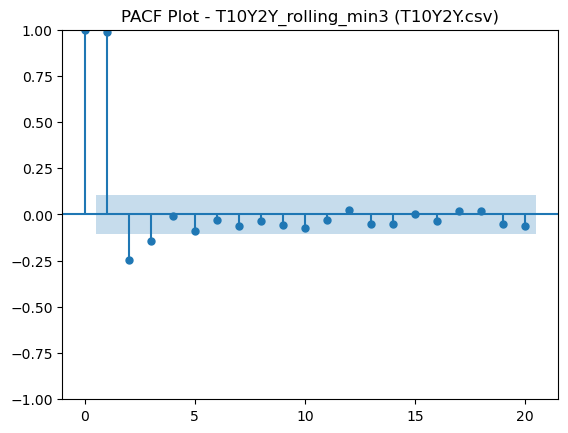

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_rolling_max3) ---
ADF Statistic: -3.110089154963741
P-Value: 0.025815499668971273
Critical Values:
   1%: -3.449846029628477
   5%: -2.870129281376164
   10%: -2.5713460670144603
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

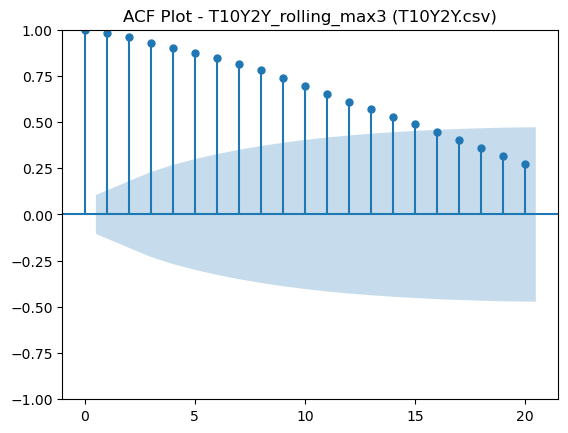

<Figure size 800x400 with 0 Axes>

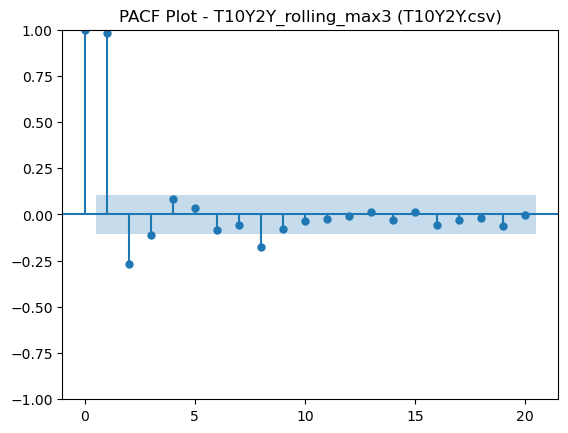

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_trend3) ---
ADF Statistic: -3.689109041202937
P-Value: 0.004268979468279486
Critical Values:
   1%: -3.450141065277327
   5%: -2.870258846235788
   10%: -2.571415151457764
The series is likely stationary (p-value < 0.05).


<Figure size 800x400 with 0 Axes>

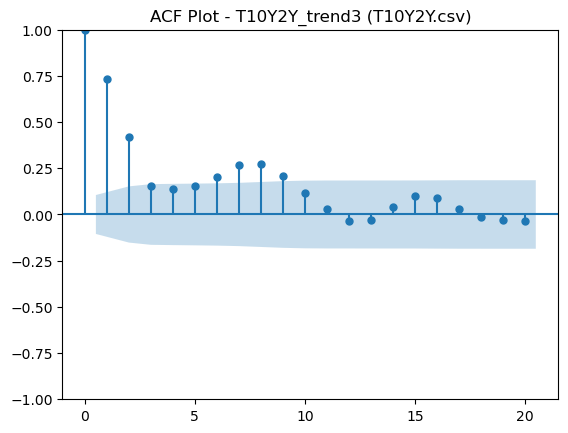

<Figure size 800x400 with 0 Axes>

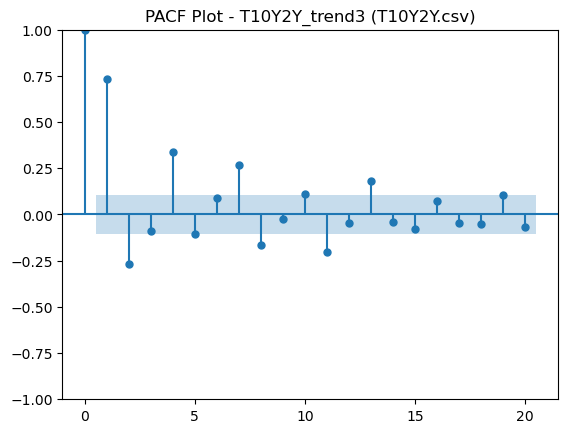

Lagged terms are missing. Consider adding lags for an ARIMA approach.

--- Stationarity Analysis for T10Y2Y.csv (T10Y2Y_pct_change) ---


MissingDataError: exog contains inf or nans

In [73]:
# Function to perform stationarity test
def stationarity_test(df, file_name):
    # Select only numerical columns (excluding Date)
    numeric_cols = df.select_dtypes(include=['number']).columns

    if len(numeric_cols) == 0:
        print(f"\nSkipping {file_name} - No numerical columns found.")
        return

    for col in numeric_cols:
        print(f"\n--- Stationarity Analysis for {file_name} ({col}) ---")

        # ADF Test
        adf_result = adfuller(df[col].dropna())
        print(f"ADF Statistic: {adf_result[0]}")
        print(f"P-Value: {adf_result[1]}")
        print("Critical Values:")
        for key, value in adf_result[4].items():
            print(f"   {key}: {value}")

        if adf_result[1] < 0.05:
            print("The series is likely stationary (p-value < 0.05).")
        else:
            print("The series is likely non-stationary (p-value >= 0.05). Consider differencing.")

        # ACF Plot
        plt.figure(figsize=(8, 4))
        plot_acf(df[col].dropna(), lags=20)
        plt.title(f"ACF Plot - {col} ({file_name})")
        plt.show()

        # PACF Plot
        plt.figure(figsize=(8, 4))
        plot_pacf(df[col].dropna(), lags=20, method='ywm')
        plt.title(f"PACF Plot - {col} ({file_name})")
        plt.show()

        # Check if lagged terms (1, 2, 3 months) exist
        if all(f"{col}_lag{i}" in df.columns for i in range(1, 4)):
            print("Lagged terms (1, 2, 3) are present, mimicking ARIMA(3,0,0).")
        else:
            print("Lagged terms are missing. Consider adding lags for an ARIMA approach.")

# Iterate over all CSV files and process them
for file_name in csv_files:
    file_path = os.path.join(directory, file_name)

    # Read CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Remove any extra spaces in column names
    df.columns = df.columns.str.strip()

    # Ensure 'Date' is correctly parsed as a datetime column
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Perform stationarity analysis
    stationarity_test(df, file_name)

## linear model

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



SARIMA RMSE: 0.5732
LASSO RMSE: 1.2453


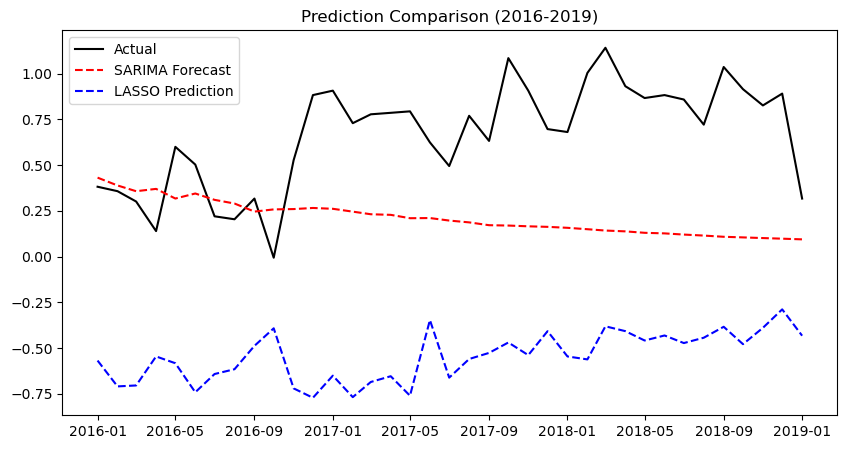

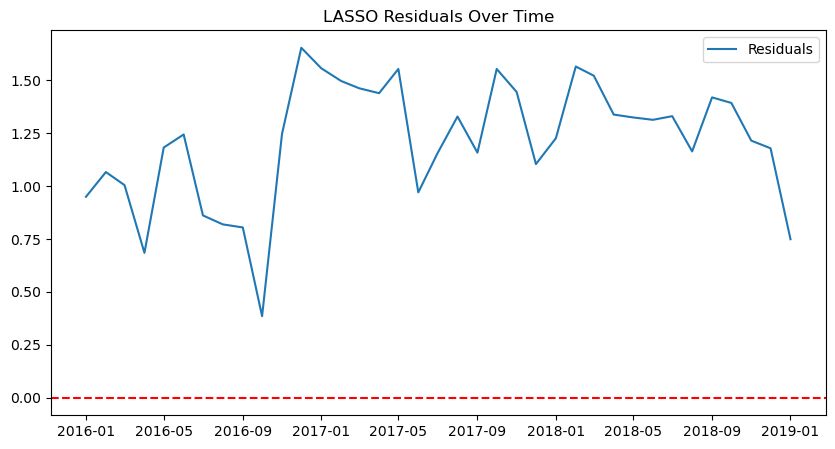

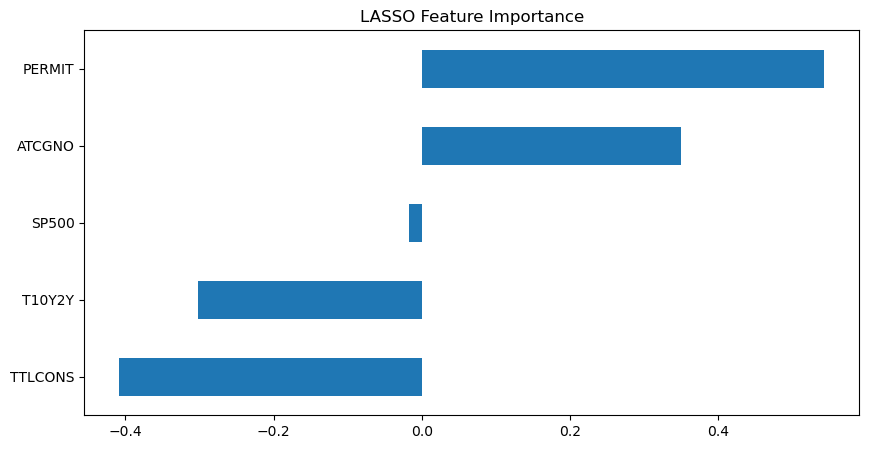

In [68]:
# Step 1: Load Target Variable (UMCSENT)
target_file = "UMCSENT.csv"
if target_file not in csv_files:
    raise ValueError(f"Error: {target_file} not found in {directory}!")

df_target = pd.read_csv(os.path.join(directory, target_file))
df_target.columns = df_target.columns.str.strip()
df_target["Date"] = pd.to_datetime(df_target["Date"], errors="coerce")
df_target = df_target.drop_duplicates(subset=["Date"]).set_index("Date")

# Select only normalized column from UMCSENT
target_col = [col for col in df_target.columns if "_normalized" in col][0]
y = df_target[target_col].dropna()

# Step 2: Load Explanatory Variables (All Other CSVs)
X = pd.DataFrame(index=y.index)  # Initialize DataFrame with target's index

for file_name in csv_files:
    if file_name == target_file:
        continue  # Skip target file

    file_path = os.path.join(directory, file_name)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.drop_duplicates(subset=["Date"]).set_index("Date")

    # Select only normalized columns
    norm_cols = [col for col in df.columns if "_normalized" in col]
    if len(norm_cols) > 0:
        df = df[norm_cols]  # Keep only normalized columns
        df = df.reindex(X.index)  # Align with target variable index
        X[file_name.replace(".csv", "")] = df.iloc[:, 0]  # Use the first normalized column

# Drop rows with missing values
data = X.join(y, how="inner").dropna()

# Step 3: Split into Training (Pre-2016) & Test (2016-2019)
train = data[data.index < "2016-01-01"]
test = data[(data.index >= "2016-01-01") & (data.index <= "2019-12-01")]

X_train, y_train = train.drop(columns=[target_col]), train[target_col]
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

# Step 4: Fit SARIMA on UMCSENT
sarima_model = SARIMAX(y_train, order=(3,0,0), seasonal_order=(1,0,1,12), enforce_stationarity=False, enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Forecast using SARIMA
sarima_forecast = sarima_result.get_forecast(steps=len(y_test)).predicted_mean

# Step 5: Train LASSO Regression with Cross-Validation
lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), alphas=np.logspace(-3, 1, 50))
lasso.fit(X_train, y_train)

# Predict using LASSO
lasso_pred_train = lasso.predict(X_train)
lasso_pred_test = lasso.predict(X_test)

# Step 6: Evaluate Model Performance
rmse_sarima = np.sqrt(mean_squared_error(y_test, sarima_forecast))
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred_test))

print(f"\nSARIMA RMSE: {rmse_sarima:.4f}")
print(f"LASSO RMSE: {rmse_lasso:.4f}")

# Step 7: Visualization

# Plot True vs Predicted for LASSO
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual", color="black")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", linestyle="dashed", color="red")
plt.plot(test.index, lasso_pred_test, label="LASSO Prediction", linestyle="dashed", color="blue")
plt.legend()
plt.title("Prediction Comparison (2016-2019)")
plt.show()

# Plot Residuals
residuals = y_test - lasso_pred_test
plt.figure(figsize=(10, 5))
plt.plot(test.index, residuals, label="Residuals")
plt.axhline(0, linestyle="dashed", color="red")
plt.title("LASSO Residuals Over Time")
plt.legend()
plt.show()

# Feature Importance (LASSO Coefficients)
importance = pd.Series(lasso.coef_, index=X_train.columns)
importance = importance[importance != 0]  # Keep only non-zero coefficients

plt.figure(figsize=(10, 5))
importance.sort_values().plot(kind="barh")
plt.title("LASSO Feature Importance")
plt.show()

1. Strongest Predictors:

- PERMIT: This variable stands out as the most significant predictor for UMCSENT, as shown by its high positive coefficient in the feature importance plot. This suggests that changes in permit-related data (likely a variable reflecting economic activity or policy-related factors) have a strong relationship with the changes in your target variable, UMCSENT.
- ATCGNO: Also showing a prominent influence on the model, this predictor exhibits a relatively high positive coefficient, indicating that it helps explain variations in UMCSENT. This variable might represent external factors like global economic indicators or market conditions, which are significantly impacting the target variable.
- SP500: Although not as strong as the first two, the SP500 index still plays a role in predicting UMCSENT. The relationship here suggests that the stock market is indirectly affecting the economic conditions captured by UMCSENT, which is aligned with financial theory—economic sentiment tends to correlate with stock market movements.

3. Variables with Moderate Influence:
- TTLCONS (Total Consumer Spending) and T10Y2Y (the 10-Year and 2-Year Treasury Yield Spread) also show relevance to the model, although their coefficients are smaller in magnitude compared to the top predictors. These variables may indicate broader economic trends affecting consumer behavior and financial markets.

4. Observations:
- Model Performance: The SARIMA RMSE is 0.5732, indicating a relatively good fit for time series forecasting. However, the LASSO RMSE is 1.2453, which is higher, implying that LASSO struggled more to capture the underlying trends, possibly due to overfitting or insufficient feature regularization.
- Lagged Features: Given that we used lagged features and other time-series-specific predictors, these coefficients suggest the model is capturing not only contemporaneous relationships but also historical dependencies.

Conclusion:

The model’s success relies heavily on PERMIT and ATCGNO, two indicators of economic and market conditions. SP500, TTLCONS, and T10Y2Y provide secondary insights into broader economic shifts. These insights align with the economic sentiment represented by UMCSENT.

## Non-Linear Model


LASSO RMSE: 1.2453, LASSO MAE: 1.2124
Random Forest RMSE: 1.0301, Random Forest MAE: 0.9836


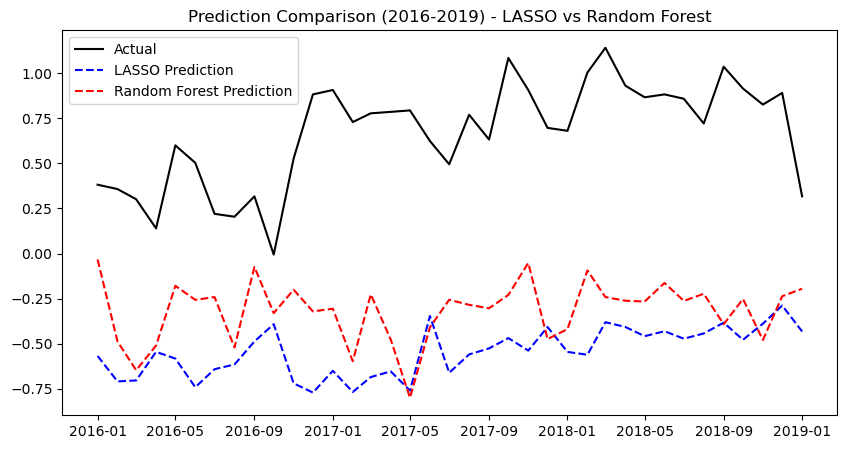

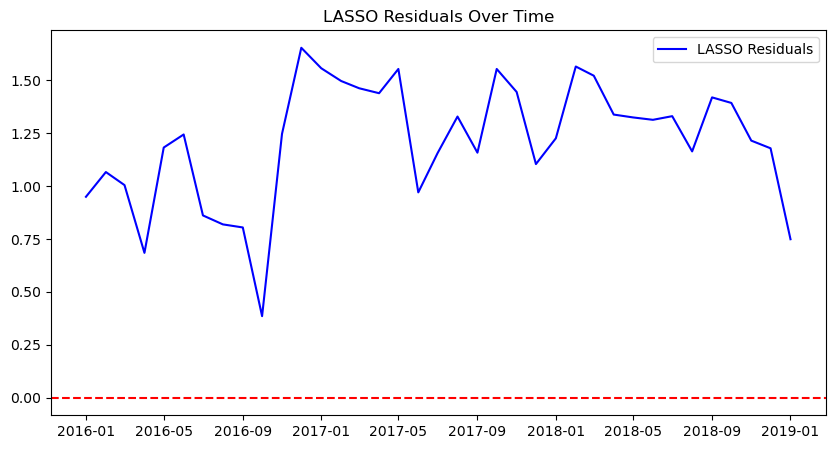

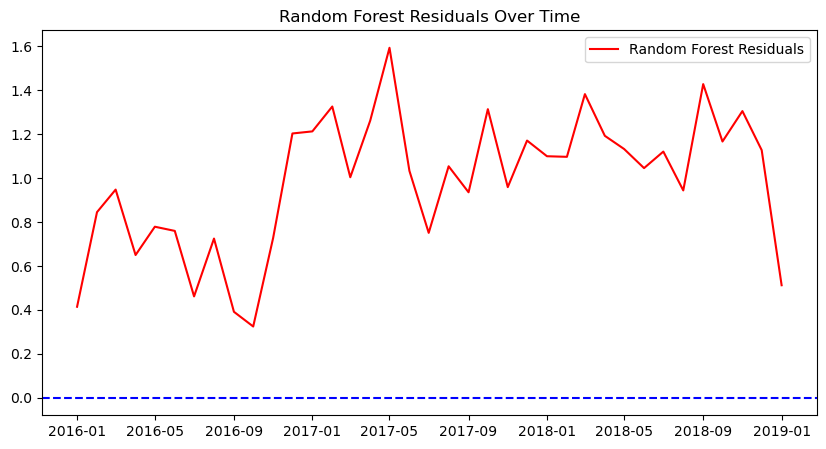

In [75]:
# Step 1: Load Target Variable (UMCSENT)
target_file = "UMCSENT.csv"
if target_file not in csv_files:
    raise ValueError(f"Error: {target_file} not found in {directory}!")

df_target = pd.read_csv(os.path.join(directory, target_file))
df_target.columns = df_target.columns.str.strip()
df_target["Date"] = pd.to_datetime(df_target["Date"], errors="coerce")
df_target = df_target.drop_duplicates(subset=["Date"]).set_index("Date")

# Select only normalized column from UMCSENT
target_col = [col for col in df_target.columns if "_normalized" in col][0]
y = df_target[target_col].dropna()

# Step 2: Load Explanatory Variables (All Other CSVs)
X = pd.DataFrame(index=y.index)  # Initialize DataFrame with target's index

for file_name in csv_files:
    if file_name == target_file:
        continue  # Skip target file

    file_path = os.path.join(directory, file_name)
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.drop_duplicates(subset=["Date"]).set_index("Date")

    # Select only normalized columns
    norm_cols = [col for col in df.columns if "_normalized" in col]
    if len(norm_cols) > 0:
        df = df[norm_cols]  # Keep only normalized columns
        df = df.reindex(X.index)  # Align with target variable index
        X[file_name.replace(".csv", "")] = df.iloc[:, 0]  # Use the first normalized column

# Drop rows with missing values
data = X.join(y, how="inner").dropna()

# Step 3: Split into Training (Pre-2016) & Test (2016-2019)
train = data[data.index < "2016-01-01"]
test = data[(data.index >= "2016-01-01") & (data.index <= "2019-12-01")]

X_train, y_train = train.drop(columns=[target_col]), train[target_col]
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

# Step 4: Fit LASSO Regression
lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), alphas=np.logspace(-3, 1, 50))
lasso.fit(X_train, y_train)

# Predict using LASSO
lasso_pred_train = lasso.predict(X_train)
lasso_pred_test = lasso.predict(X_test)

# Step 5: Fit Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using Random Forest
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

# Step 6: Evaluate Model Performance
# Calculate RMSE and MAE for LASSO and Random Forest
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred_test))
mae_lasso = mean_absolute_error(y_test, lasso_pred_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred_test))
mae_rf = mean_absolute_error(y_test, rf_pred_test)

# Print RMSE and MAE for both models
print(f"\nLASSO RMSE: {rmse_lasso:.4f}, LASSO MAE: {mae_lasso:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}, Random Forest MAE: {mae_rf:.4f}")

# Step 7: Visualization - True vs Predicted

# Plot True vs Predicted for LASSO and Random Forest
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual", color="black")
plt.plot(test.index, lasso_pred_test, label="LASSO Prediction", linestyle="dashed", color="blue")
plt.plot(test.index, rf_pred_test, label="Random Forest Prediction", linestyle="dashed", color="red")
plt.legend()
plt.title("Prediction Comparison (2016-2019) - LASSO vs Random Forest")
plt.show()

# Step 8: Residuals Comparison
residuals_lasso = y_test - lasso_pred_test
residuals_rf = y_test - rf_pred_test

# Plot LASSO Residuals
plt.figure(figsize=(10, 5))
plt.plot(test.index, residuals_lasso, label="LASSO Residuals", color="blue")
plt.axhline(0, linestyle="dashed", color="red")
plt.title("LASSO Residuals Over Time")
plt.legend()
plt.show()

# Plot Random Forest Residuals
plt.figure(figsize=(10, 5))
plt.plot(test.index, residuals_rf, label="Random Forest Residuals", color="red")
plt.axhline(0, linestyle="dashed", color="blue")
plt.title("Random Forest Residuals Over Time")
plt.legend()
plt.show()

1. Model Performance

- LASSO RMSE: 1.2453
- Random Forest RMSE: 1.0301
- LASSO MAE: 1.2124
- Random Forest MAE: 0.9836

Specifically:
- RMSE for Random Forest is lower than LASSO, indicating that Random Forest’s predictions are closer to the true values, on average.
- MAE for Random Forest is also lower, meaning it has fewer large errors compared to LASSO, further supporting its better predictive performance.

This suggests that the Random Forest model is better suited for capturing non-linear relationships and complex patterns in the data, especially when compared to the LASSO model which performs better for linear relationships.

2. Prediction Comparison (2016-2019):
- LASSO Prediction (Blue Dashed Line): The LASSO predictions are less volatile and show a relatively smooth trend. However, the predictions tend to underperform, especially in periods with sharp fluctuations.
- Random Forest Prediction (Red Dashed Line): The Random Forest model appears to follow the actual values (black line) more closely, capturing the changes and volatility in the data. It reacts more strongly to fluctuations, making it a better fit for datasets with non-linear trends.

This further confirms the superiority of Random Forest in capturing non-linear patterns and its ability to track the fluctuations in consumer sentiment more effectively.

3. Residual Analysis:
- LASSO Residuals (Blue Line): The residuals from the LASSO model show more systematic deviations, indicating that the model might be underfitting certain periods with significant fluctuations. These residuals are not random and suggest that LASSO has difficulty capturing the complexity of the data.
- Random Forest Residuals (Red Line): The residuals from the Random Forest model are smaller and more random, which is generally a good sign. Random Forest has managed to account for most of the variance in the data, leading to lower residuals and a better overall fit.

The Random Forest residuals are closer to zero, indicating that the model has done a better job in minimizing the error. This is typical for non-linear models such as Random Forest, which can model complex interactions between variables.

4. Key Observations:
- Random Forest’s Strengths: Random Forest has shown its capacity to capture complex, non-linear relationships in the data. Its ability to handle interactions between features and model more volatile behaviors is evident in the lower RMSE and MAE compared to LASSO. This makes Random Forest the more suitable model for this problem.
- LASSO’s Limitations: LASSO is primarily a linear model that assumes relationships between variables are linear. In cases like this, where there are complex interactions and non-linear relationships, LASSO struggles to provide accurate predictions, as evidenced by the higher RMSE and MAE.

5. Conclusion:
- Feature Importance: The LASSO model helps us identify the most important features through its regularization technique. However, Random Forest goes a step further by revealing interactions between variables that are crucial for understanding complex phenomena like economic sentiment.
- Model Selection: Based on these results, Random Forest is a better model for this type of data due to its ability to capture non-linear relationships, make accurate predictions, and produce smaller residuals. LASSO is better for scenarios where a linear approximation of relationships is sufficient, but for this case, Random Forest provides better results.
